# 1. 어느 조합을 다음 단계로 가져갈까?

03에서 본 후보를 **같은 날짜·같은 입력 창**으로 다시 비교한다. 목표는 오늘 종가를 확인한 뒤
5·20·60거래일 후의 로그수익률을 예측하는 것. 가격은 `오늘 종가 × exp(예측 수익률)`로 환산한다.

| 지평 | 피처 그룹 | 그룹마다 비교할 모델 | 가격 단변량 기준 | 후보 수 |
|---|---|---|---|---:|
| 5일 | 가격+거시 / 전체 | CatBoost·LightGBM·Attention-LSTM | ARIMA·지수평활 | 8 |
| 20일 | 가격+거시 / 전체 | CatBoost·LightGBM·Attention-LSTM | ARIMA·지수평활 | 8 |
| 60일 | 가격+거시 / 가격+기후 / 전체 | CatBoost·LightGBM·DLinear·LSTM·Attention-LSTM | — | 15 |

31개 후보와 지평별 가격 유지(Naive) 3개를 비교한다. ARIMA와 지수평활은 외생변수를 사용하지 않아
그룹별로 반복하지 않는다. 후보가 모두 기존 지표의 상위 모델이었던 것은 아니다.

**선택 기준은 Validation RMSE**다. MAE와 방향 정확도는 함께 읽는다. 이번 후보 자체가 이미 확인한
Test 결과를 참고했으므로, 새로운 독립 검증이라고 부르지 않는다. 현재 Yahoo·NASA 자료를 사용하는
연구용 비교이며 원천 자료의 과거 수정 이력까지 복원하지는 못했다.

In [1]:
import os
import platform
from pathlib import Path

# Mac 밖에서도 같은 그림을 읽을 수 있게 첫 셀에서 폰트를 정한다.
for key in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[key] = "1"
os.environ["PYCARET_CUSTOM_LOGGING_PATH"] = os.devnull

import tempfile
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "coffee-matplotlib"))
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
import seaborn as sns
import pandas_market_calendars as mcal
from IPython.display import Markdown, display

FONT = {"Windows": "Malgun Gothic", "Darwin": "AppleGothic"}.get(platform.system(), "NanumGothic")
# Linux/Colab: !apt-get -qq install fonts-nanum 후 커널을 다시 시작한다.
if not any(f.name == FONT for f in font_manager.fontManager.ttflist):
    raise RuntimeError(f"{FONT} 설치가 필요합니다. Linux/Colab은 fonts-nanum 패키지를 설치하세요.")
plt.rc("font", family=FONT)
sns.set_theme(style="whitegrid", font=FONT, palette="colorblind")
plt.rcParams.update({"axes.unicode_minus": False, "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False, "grid.alpha": 0.2})

ROOT = Path.cwd() if (Path.cwd() / "configs").exists() else Path.cwd().parent
DATA = ROOT / "data/processed/2014-07-01_2025-12-31"
SEED, LOOKBACK = 42, 60  # 입력 창과 예측 지평은 서로 다른 설정이다.
HORIZONS = (5, 20, 60)
TRAIN_START, TRAIN_END = pd.Timestamp("2015-01-01"), pd.Timestamp("2021-12-31")
VAL_END, TEST_END = pd.Timestamp("2023-12-31"), pd.Timestamp("2025-12-31")
WEATHER_DELAY = 4  # 관측일+4달력일 가정. 실제 과거 공개 시점을 검증한 값은 아니다.

REGIONS = {"br_sul_minas": "술 지 미나스", "br_cerrado": "세라도", "br_alta_mogiana": "알타 모지아나",
           "co_huila": "우일라", "co_caldas": "칼다스", "co_antioquia": "안티오키아"}
PRICE = ["return_1", "return_5", "return_20", "volatility_20"]
MACRO = ["brl_change_20", "rate_change_20", "oil_change_20"]
LABELS = {"close": "커피 종가", "return_1": "1일 수익률", "return_5": "5일 수익률",
          "return_20": "20일 수익률", "volatility_20": "20일 변동성",
          "brl_change_20": "환율 20일 로그변화", "rate_change_20": "금리 20일 차이",
          "oil_change_20": "유가 20일 차이", "month_sin": "월 주기 sin", "month_cos": "월 주기 cos"}
for region, label in REGIONS.items():
    for key, suffix in {"rain_anomaly": "30일 강수 편차", "temp_anomaly": "30일 기온 편차",
                        "drought": "90일 강수 결손", "frost": "7일 격자 서리 강도",
                        "drought_frost": "가뭄 × 격자 서리"}.items():
        LABELS[f"{region}_{key}"] = f"{label} · {suffix}"

def show_table(frame, digits=5):
    frame = frame.copy()
    if "설정" in frame:
        frame["설정"] = frame["설정"].replace({0: "고정"})
    if "구간" in frame:
        frame["구간"] = frame["구간"].replace({"Train": "학습", "Validation": "검증", "Test": "평가"})
    display(Markdown(frame.to_markdown(index=False, floatfmt=f".{digits}f")))

print(f"Python {platform.python_version()} · 폰트 {FONT} · seed {SEED}")

Python 3.12.14 · 폰트 AppleGothic · seed 42


# 2. 날짜를 맞추고 60일 입력 창 만들기

Train은 2015~2021, Validation은 2022~2023, Test는 2024~2025다. 정답 날짜도 각 구간 안에 있어야 한다.
2014년 자료는 집계·입력 창의 버퍼로만 쓴다. 거래일 전체에서 먼저 시차를 계산하고, 가격이 빠진 칸은 그대로 둔다.

거시는 ALFRED 최초 공개값을 공개 날짜 다음 날부터 붙인다. NASA는 관측일+4달력일이라는 기존 연구용 가정을 유지한다.
기상 기준 평균은 해당 학습 기간에서만 계산하며 결측 대치에 쓰지 않는다. COT와 소급 달러지수는 입력에서 제외한다.

In [2]:
sources = {}
for path in sorted(DATA.glob("*.parquet")):
    frame = pd.read_parquet(path).sort_values("date").reset_index(drop=True)
    frame["date"] = pd.to_datetime(frame.date).astype("datetime64[ns]")
    assert frame.date.is_unique and frame.date.notna().all(), path.name
    sources[path.stem] = frame
assert len(sources) == 15, "Core-4 12개와 ALFRED 최초 공개값 3개가 필요합니다."
source_names = {"coffee": "커피", "brl": "Yahoo 환율", "dff": "현재 금리", "dtwexbgs": "현재 달러지수",
                "dcoilwtico": "현재 WTI", "cot": "COT", "alfred_dexbzus": "최초 공개 환율",
                "alfred_dff": "최초 공개 금리", "alfred_dcoilwtico": "최초 공개 WTI",
                **{f"weather_{k}": f"{v} 기상" for k,v in REGIONS.items()}}
show_table(pd.DataFrame([{"자료": source_names[k], "행 수": len(v), "시작": str(v.date.min().date()),
                          "끝": str(v.date.max().date()), "결측 셀": int(v.isna().sum().sum())}
                         for k,v in sources.items()]), 0)

def coffee_sessions(start, end):
    # NYSE와 다른 커피 거래일 두 날짜를 보완한다. 일반 ICEUS 달력은 상품별 휴일이 다르다.
    days = mcal.get_calendar("NYSE").valid_days(start, end).tz_localize(None).as_unit("ns")
    days = days.union(pd.to_datetime(["2018-12-05", "2025-01-09"])).sort_values()
    return days[(days >= pd.Timestamp(start)) & (days <= pd.Timestamp(end))]

SESSIONS = coffee_sessions("2014-07-01", "2025-12-31")
prices = sources["coffee"].set_index("date").close.reindex(SESSIONS).rename("close")
print("거래일 가격 누락:", prices.index[prices.isna()].strftime("%Y-%m-%d").tolist())
print("휴장일 원응답 제외:", sources["coffee"].loc[~sources["coffee"].date.isin(SESSIONS), "date"].dt.strftime("%Y-%m-%d").tolist())

| 자료               |   행 수 | 시작       | 끝         |   결측 셀 |
|:-------------------|--------:|:-----------|:-----------|----------:|
| 최초 공개 WTI      |    3000 | 2014-07-01 | 2025-12-29 |       120 |
| 최초 공개 환율     |    2999 | 2014-07-01 | 2025-12-26 |       132 |
| 최초 공개 금리     |    4201 | 2014-07-01 | 2025-12-30 |         0 |
| Yahoo 환율         |    3002 | 2014-07-01 | 2025-12-31 |        28 |
| 커피               |    2899 | 2014-07-01 | 2025-12-31 |        20 |
| COT                |     601 | 2014-07-01 | 2025-12-30 |         0 |
| 현재 WTI           |    3002 | 2014-07-01 | 2025-12-31 |       121 |
| 현재 금리          |    4202 | 2014-07-01 | 2025-12-31 |         0 |
| 현재 달러지수      |    3002 | 2014-07-01 | 2025-12-31 |       136 |
| 알타 모지아나 기상 |    4262 | 2014-06-01 | 2026-01-30 |         0 |
| 세라도 기상        |    4262 | 2014-06-01 | 2026-01-30 |         0 |
| 술 지 미나스 기상  |    4262 | 2014-06-01 | 2026-01-30 |         0 |
| 안티오키아 기상    |    4262 | 2014-06-01 | 2026-01-30 |         0 |
| 칼다스 기상        |    4262 | 2014-06-01 | 2026-01-30 |         0 |
| 우일라 기상        |    4262 | 2014-06-01 | 2026-01-30 |         0 |

거래일 가격 누락: ['2014-09-18', '2016-10-10', '2016-11-11', '2018-12-05']
휴장일 원응답 제외: ['2016-01-18', '2016-02-15', '2023-11-23', '2025-05-26', '2025-06-19', '2025-07-04']


In [3]:
def align_available(frame, columns, max_age):
    """관측일과 별도로 지정한 available_at 이전 값만 가져온다."""
    left = pd.DataFrame({"date": SESSIONS})
    right = frame.sort_values(["available_at", "date"]).copy()
    # 같은 날 여러 과거 관측이 공개되면 그중 가장 최근 관측을 쓴다.
    right = right.loc[right.date.eq(right.date.cummax())]
    right = right.rename(columns={"date": "observed_at"})
    joined = pd.merge_asof(left, right[["observed_at", "available_at", *columns]],
                           left_on="date", right_on="available_at", direction="backward",
                           tolerance=None if max_age is None else pd.Timedelta(days=max_age))
    valid = joined.available_at.notna()
    assert (joined.loc[valid, "available_at"] <= joined.loc[valid, "date"]).all()
    assert (joined.loc[valid, "observed_at"] <= joined.loc[valid, "available_at"]).all()
    return joined.set_index("date")


def build_features(data, fit_end):
    close = data["coffee"].set_index("date").close.reindex(SESSIONS)
    features = pd.DataFrame(index=SESSIONS)
    log_price = np.log(close)
    for days in (1, 5, 20):
        features[f"return_{days}"] = log_price.diff(days)
    features["volatility_20"] = log_price.diff().rolling(20, min_periods=20).std()
    availability, weather_columns, warmup = {}, [], []
    for name, output, logarithm in [("dexbzus", "brl", True), ("dff", "rate", False),
                                     ("dcoilwtico", "oil", False)]:
        raw = data[f"alfred_{name}"].dropna(subset=["value"]).copy()
        raw["available_at"] = pd.to_datetime(raw.release_date) + pd.Timedelta(days=1)
        joined = align_available(raw, ["value"], max_age=None)
        values = np.log(joined.value) if logarithm else joined.value
        features[f"{output}_change_20"] = values.diff(20)
        availability[output] = joined[["observed_at", "available_at"]]
    for region in REGIONS:
        raw = data[f"weather_{region}"].set_index("date").reindex(
            pd.date_range(data[f"weather_{region}"].date.min(), data[f"weather_{region}"].date.max()))
        daily = pd.DataFrame(index=raw.index)
        daily["rain30"] = raw.PRECTOTCORR.rolling(30, min_periods=30).sum()
        daily["rain90"] = raw.PRECTOTCORR.rolling(90, min_periods=90).sum()
        daily["temp30"] = raw.T2M.rolling(30, min_periods=30).mean()
        # 서리 직전 가뭄을 보려면 서리가 포함된 7일을 강수 누적에서 빼야 한다.
        daily["prior_rain90"] = daily.rain90.shift(7)
        daily["frost7"] = (-raw.T2M_MIN).clip(lower=0).rolling(7, min_periods=7).sum()
        fit = daily.loc[TRAIN_START:pd.Timestamp(fit_end) - pd.Timedelta(days=WEATHER_DELAY)]
        normal = fit.groupby(fit.index.month)[["rain30", "rain90", "temp30", "prior_rain90"]].mean()
        reference = normal.reindex(daily.index.month).set_axis(daily.index)
        derived = pd.DataFrame({f"{region}_rain_anomaly": daily.rain30 - reference.rain30,
                                f"{region}_temp_anomaly": daily.temp30 - reference.temp30,
                                f"{region}_drought": (reference.rain90 - daily.rain90).clip(lower=0)}, index=daily.index)
        if region.startswith("br_"):
            derived[f"{region}_frost"] = daily.frost7
            derived[f"{region}_drought_frost"] = (reference.prior_rain90 - daily.prior_rain90).clip(lower=0) * daily.frost7
        derived = derived.rename_axis("date").reset_index()
        derived["available_at"] = derived.date + pd.Timedelta(days=WEATHER_DELAY)
        columns = [c for c in derived if c not in ("date", "available_at")]
        joined = align_available(derived, columns, max_age=4)
        features[columns] = joined[columns]
        weather_columns.extend(columns)
        availability[region] = joined[["observed_at", "available_at"]]
        warmup.append({"산지": REGIONS[region], "첫 학습일 결측": int(joined.loc["2015-01-02", columns].isna().sum()),
                       "학습 기간 기상 결측": int(joined.loc[TRAIN_START:TRAIN_END, columns].isna().sum().sum())})
    features["month_sin"] = np.sin(2 * np.pi * features.index.month / 12)
    features["month_cos"] = np.cos(2 * np.pi * features.index.month / 12)
    weather_columns += ["month_sin", "month_cos"]
    return features, weather_columns, availability, pd.DataFrame(warmup)

X, WEATHER_ALL, availability, warmup = build_features(sources, TRAIN_END)
WEATHER = [c for c in WEATHER_ALL if X.loc[TRAIN_START:TRAIN_END, c].nunique() > 1]
CONSTANTS = [c for c in WEATHER_ALL if c not in WEATHER]
FEATURES = PRICE + MACRO + WEATHER
show_table(warmup, 0)
assert warmup.iloc[:, 1:].to_numpy().sum() == 0
print("학습에서 상수인 기상 피처 제외:", [LABELS[c] for c in CONSTANTS])

| 산지          |   첫 학습일 결측 |   학습 기간 기상 결측 |
|:--------------|-----------------:|----------------------:|
| 술 지 미나스  |                0 |                     0 |
| 세라도        |                0 |                     0 |
| 알타 모지아나 |                0 |                     0 |
| 우일라        |                0 |                     0 |
| 칼다스        |                0 |                     0 |
| 안티오키아    |                0 |                     0 |

학습에서 상수인 기상 피처 제외: ['술 지 미나스 · 7일 격자 서리 강도', '술 지 미나스 · 가뭄 × 격자 서리', '세라도 · 7일 격자 서리 강도', '세라도 · 가뭄 × 격자 서리', '알타 모지아나 · 7일 격자 서리 강도', '알타 모지아나 · 가뭄 × 격자 서리']


In [4]:
def make_targets(close):
    result = pd.DataFrame(index=close.index)
    dates = pd.Series(close.index, index=close.index)
    for h in HORIZONS:
        result[f"y_{h}"] = np.log(close.shift(-h) / close)
        result[f"target_date_{h}"] = dates.shift(-h)
    return result


def eligible_rows(features, targets, h, start, end):
    # 먼저 거래일 전체에서 계산한다. dropna 뒤 shift를 하면 1일의 길이가 달라진다.
    valid = features[FEATURES].notna().all(axis=1).rolling(LOOKBACK, min_periods=LOOKBACK).sum().eq(LOOKBACK)
    valid &= targets[f"y_{h}"].notna() & targets[f"target_date_{h}"].le(end)
    valid &= (features.index >= pd.Timestamp(start)) & (features.index <= pd.Timestamp(end))
    return np.flatnonzero(valid)

Y = make_targets(prices)
SPLITS = {}
rows = []
for h in HORIZONS:
    SPLITS[h] = {}
    for name, start, end in [("Train", TRAIN_START, TRAIN_END), ("Validation", "2022-01-01", VAL_END),
                             ("Test", "2024-01-01", TEST_END)]:
        indices = eligible_rows(X, Y, h, start, pd.Timestamp(end))
        SPLITS[h][name] = indices
        assert Y.iloc[indices][f"target_date_{h}"].max() <= pd.Timestamp(end)
        rows.append({"지평": h, "구간": name, "유효 행": len(indices),
                     "첫 예측일": str(SESSIONS[indices[0]].date()), "마지막 예측일": str(SESSIONS[indices[-1]].date())})
show_table(pd.DataFrame(rows), 0)

assert len(FEATURES) == 27 and len(WEATHER) == 20
EXPECTED = {5: (1566, 496, 498), 20: (1551, 481, 483), 60: (1510, 441, 443)}
for h in HORIZONS:
    assert tuple(len(SPLITS[h][s]) for s in ("Train", "Validation", "Test")) == EXPECTED[h]
    assert SESSIONS[SPLITS[h]["Train"][0]] == pd.Timestamp("2015-01-13")

GROUP_COLUMNS = {"가격+거시": PRICE+MACRO, "가격+기후": PRICE+WEATHER,
                 "가격+거시+기후": FEATURES}
EXPERIMENTS = {}
for h in HORIZONS:
    groups = ("가격+거시", "가격+거시+기후") if h != 60 else tuple(GROUP_COLUMNS)
    families = ("CatBoost", "LightGBM", "Attention-LSTM") if h != 60 else (
        "CatBoost", "LightGBM", "DLinear", "LSTM", "Attention-LSTM")
    EXPERIMENTS[h] = [(family, group) for group in groups for family in families]
assert sum(map(len, EXPERIMENTS.values())) == 27  # 외생변수 후보 27 + 단변량 후보 4

|   지평 | 구간   |   유효 행 | 첫 예측일   | 마지막 예측일   |
|-------:|:-------|----------:|:------------|:----------------|
|      5 | 학습   |      1566 | 2015-01-13  | 2021-12-23      |
|      5 | 검증   |       496 | 2022-01-03  | 2023-12-21      |
|      5 | 평가   |       498 | 2024-01-02  | 2025-12-23      |
|     20 | 학습   |      1551 | 2015-01-13  | 2021-12-02      |
|     20 | 검증   |       481 | 2022-01-03  | 2023-11-30      |
|     20 | 평가   |       483 | 2024-01-02  | 2025-12-02      |
|     60 | 학습   |      1510 | 2015-01-13  | 2021-10-06      |
|     60 | 검증   |       441 | 2022-01-03  | 2023-10-04      |
|     60 | 평가   |       443 | 2024-01-02  | 2025-10-06      |

60일은 **입력 창**, 5·20·60일은 **예측 지평**이다. 두 설정은 별개다.
버퍼의 가격 누락이 20일 변동성과 60일 창에 남아 첫 유효 학습일은 2015-01-13이 됐다.
초기 날짜를 억지로 채우지 않고, 모든 모델에 같은 유효 사례를 적용한다.

가격+거시는 7개, 가격+기후는 24개, 전체는 27개 피처다. 기후에는 월 주기 sin·cos도 포함한다.
03에서 상수였던 격자 서리·가뭄×서리 6개는 계속 제외한다.

# 3. 모델을 같은 규칙으로 학습하기

트리 모델은 현재 행의 과거 집계 피처를, 신경망은 `(사례 수, 60, 피처 수)`를 받는다.
일반 LSTM과 Attention-LSTM은 **은닉 64·2층·dropout 0.1·동일 출력층**으로 맞춘다.
Attention-LSTM은 학부 코드의 Entmax와 gate를 유지하되, 거시·기후도 시간에 따라 변하는 입력으로 넣는다.

과거 코드의 여러 날 가격 경로 대신 지평별 수익률 하나를 출력한다. Test 기반 학습률 조정과 복합 손실은 사용하지 않는다.
세 신경망은 MSE·AdamW·학습률 0.001·weight decay 0.01·batch 64·gradient clipping 1로 통일한다.
DLinear는 03의 분해 선형 구조를 단일 수익률 출력으로 바꾼 변형이다.

트리 수는 150/300, epoch는 50/100만 비교한다. CPU·seed 42, 조기 종료 없이 실행한다.
50 epoch 결과는 100 epoch까지 가는 같은 학습 과정에서 저장한다.

In [5]:
import copy
import time
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from entmax import entmax15
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
NEURAL = ("DLinear", "LSTM", "Attention-LSTM")
SETTINGS = {"CatBoost": (150, 300), "LightGBM": (150, 300),
            **{family: (50, 100) for family in NEURAL}}
def metrics(actual, predicted):
    actual, predicted = np.asarray(actual), np.asarray(predicted)
    assert actual.shape == predicted.shape and np.isfinite(predicted).all()
    rmse = root_mean_squared_error(actual, predicted)
    naive = root_mean_squared_error(actual, np.zeros_like(actual))
    return {"RMSE": rmse, "MAE": mean_absolute_error(actual, predicted),
            "방향 정확도 (%)": 100*np.mean(np.sign(actual) == np.sign(predicted)),
            "Naive 대비 개선 (%)": 100*(1-rmse/naive)}


def catboost(trees=150):
    return CatBoostRegressor(iterations=trees, depth=4, learning_rate=.03, l2_leaf_reg=5,
                             loss_function="RMSE", random_seed=SEED, verbose=False,
                             thread_count=1, allow_writing_files=False)

In [6]:
def make_sequences(values, indices, lookback=LOOKBACK):
    indices = np.asarray(indices)
    assert len(indices) and indices.min() >= lookback-1
    windows = np.stack([values[i-lookback+1:i+1] for i in indices])
    assert windows.shape == (len(indices), lookback, values.shape[1])
    assert np.isfinite(windows).all()
    return windows


class ReturnNetwork(nn.Module):
    def __init__(self, n_features, kind):
        super().__init__()
        self.kind = kind
        if kind == "DLinear":
            self.trend = nn.Linear(LOOKBACK, 1)
            self.residual = nn.Linear(LOOKBACK, 1)
            self.head = nn.Linear(n_features, 1)
        else:
            self.lstm = nn.LSTM(n_features, 64, num_layers=2, dropout=.1, batch_first=True)
            self.head = nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 32),
                                      nn.ReLU(), nn.Linear(32, 1))
            if kind == "Attention-LSTM":
                self.score = nn.Sequential(nn.Linear(64, 64), nn.Tanh(), nn.Linear(64, 1))
                self.gate = nn.Sequential(nn.Linear(128, 1), nn.Sigmoid())

    def forward(self, x, return_attention=False):
        weights = None
        if self.kind == "DLinear":
            channels = x.transpose(1, 2)
            smooth = nn.functional.avg_pool1d(
                nn.functional.pad(channels, (2, 2), mode="replicate"), 5, stride=1)
            value = (self.trend(smooth) + self.residual(channels-smooth)).squeeze(-1)
        else:
            hidden, _ = self.lstm(x)
            value = hidden[:, -1, :]
            if self.kind == "Attention-LSTM":
                weights = entmax15(self.score(hidden).squeeze(-1), dim=1)
                context = (hidden * weights.unsqueeze(-1)).sum(dim=1)
                alpha = self.gate(torch.cat([context, value], dim=1))
                value = alpha*context + (1-alpha)*value
        prediction = self.head(value).squeeze(-1)
        return (prediction, weights) if return_attention else prediction


def fit_neural_candidates(family, settings, features, columns, target, train_indices, eval_indices):
    torch.manual_seed(SEED)
    rng = torch.Generator().manual_seed(SEED)
    scaler = StandardScaler().fit(features.iloc[train_indices][columns])
    values = scaler.transform(features[columns]).astype("float32")
    train_x = make_sequences(values, train_indices)
    eval_x = torch.from_numpy(make_sequences(values, eval_indices))
    train_y = target.iloc[train_indices].to_numpy()
    y_mean, y_std = float(train_y.mean()), float(train_y.std())
    assert y_std > 0 and np.isfinite(train_y).all()
    train_y_scaled = ((train_y-y_mean)/y_std).astype("float32")
    loader = DataLoader(TensorDataset(torch.from_numpy(train_x), torch.from_numpy(train_y_scaled)),
                        batch_size=64, shuffle=True, generator=rng)
    model = ReturnNetwork(len(columns), family)
    optimizer = torch.optim.AdamW(model.parameters(), lr=.001, weight_decay=.01)
    results = {}
    for epoch in range(1, max(settings)+1):
        model.train()
        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            loss = nn.functional.mse_loss(model(batch_x), batch_y)
            assert torch.isfinite(loss)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.)
            optimizer.step()
        if epoch in settings:
            model.eval()
            with torch.no_grad():
                pred = model(eval_x).numpy()*y_std+y_mean
            assert np.isfinite(pred).all()
            results[epoch] = (pred, {"model": copy.deepcopy(model), "scaler": scaler,
                                     "y_mean": y_mean, "y_std": y_std, "columns": list(columns)})
    return results


def fit_candidates(family, settings, features, columns, target, train_indices, eval_indices):
    if family in NEURAL:
        return fit_neural_candidates(family, settings, features, columns, target, train_indices, eval_indices)
    results = {}
    for setting in settings:
        model = catboost(setting) if family == "CatBoost" else LGBMRegressor(
            n_estimators=setting, max_depth=4, num_leaves=15, min_child_samples=40,
            learning_rate=.03, reg_lambda=5, random_state=SEED, n_jobs=1,
            verbosity=-1, deterministic=True, force_col_wise=True)
        model.fit(features.iloc[train_indices][columns], target.iloc[train_indices])
        pred = model.predict(features.iloc[eval_indices][columns])
        assert np.isfinite(pred).all()
        results[setting] = (pred, {"model": model, "columns": list(columns)})
    return results

**가격 단변량 기준**은 03과 같은 PyCaret 연결을 쓴다. 공개된 새 가격이 들어오면 상태공간 필터의 상태만
갱신하고, Validation/Test 도중 모수를 다시 맞추지 않는다. 빠진 가격은 관측 갱신을 건너뛰며 대치하지 않는다.
통계 모델의 가격 학습 이력은 2015년 첫 거래일부터다. 평가는 신경망·트리와 같은 예측일에서 수행한다.

In [7]:
from pycaret.time_series import TimeSeriesExperiment
from sktime.forecasting.base import BaseForecaster
from statsmodels.tsa.statespace.exponential_smoothing import ExponentialSmoothing as StateSpaceSES
from statsmodels.tsa.statespace.sarimax import SARIMAX

class PriceForecaster(BaseForecaster):
    """PyCaret에 거래일 결측을 유지하는 상태공간 모델을 연결한다."""
    _tags = {"capability:missing_values": True, "capability:exogenous": False,
             "requires-fh-in-fit": False, "y_inner_mtype": "pd.Series"}

    def __init__(self, kind="ses"):
        self.kind = kind
        super().__init__()

    def _fit(self, y, X=None, fh=None):
        if self.kind == "ses":
            estimator = StateSpaceSES(y, initialization_method="estimated")
        else:
            estimator = SARIMAX(y, order=(1, 1, 0), trend="n", concentrate_scale=True)
        self.result_ = estimator.fit(method="powell", disp=False, maxiter=300)
        assert self.result_.mle_retvals["converged"], f"{self.kind}: 학습 수렴 확인 필요"
        return self

    def _update(self, y, X=None, update_params=True):
        if update_params:
            raise ValueError("평가에서는 고정 모수로 상태만 갱신합니다.")
        self.result_ = self.result_.append(y, refit=False)
        return self

    def _predict(self, fh, X=None):
        steps = fh.to_relative(self.cutoff).to_numpy().astype(int)
        values = np.asarray(self.result_.forecast(int(steps.max())))[steps - 1]
        return pd.Series(values, index=fh.to_absolute(self.cutoff).to_pandas(), name=self._y.name)


def univariate_predictions(fit_end, evaluation_indices):
    horizons = tuple(evaluation_indices)
    first = int(np.flatnonzero(SESSIONS >= TRAIN_START)[0])
    y = np.log(prices.iloc[first:]).reset_index(drop=True).rename("로그가격")
    last_train = int(np.flatnonzero(SESSIONS <= pd.Timestamp(fit_end))[-1]) - first
    history = y.iloc[:last_train+1]
    assert history.notna().iloc[[0, -1]].all()
    experiment = TimeSeriesExperiment(fh=list(horizons), seasonal_period=1, preprocess=False,
                                       session_id=SEED, n_jobs=1).fit(history)
    pd.testing.assert_series_equal(experiment.y, history)
    origins = sorted(set(np.concatenate(list(evaluation_indices.values()))))
    result = {h: {"가격 유지": pd.Series(0., index=evaluation_indices[h])} for h in horizons}
    for label, kind in [("지수평활", "ses"), ("ARIMA(1,1,0)", "arima")]:
        created = experiment.create_model(PriceForecaster(kind), cross_validation=False)
        model = created.pipeline.clone().fit(history, fh=list(horizons))
        by_horizon = {h: {} for h in horizons}
        for global_origin in origins:
            origin, last_seen = global_origin-first, int(model.cutoff[0])
            if origin > last_seen:
                model.update(y.iloc[last_seen+1:origin+1], update_params=False)
            forecast = model.predict(fh=list(horizons))
            assert int(model.cutoff[0]) == origin
            np.testing.assert_array_equal(forecast.index, origin + np.array(horizons))
            for h, value in zip(horizons, forecast):
                if global_origin in evaluation_indices[h]:
                    by_horizon[h][global_origin] = value - y.iloc[origin]
        for h in horizons:
            result[h][label] = pd.Series(by_horizon[h]).reindex(evaluation_indices[h])
        print(f"{fit_end.date()}까지 학습 · {label} 상태 갱신 완료", flush=True)
    return result

In [8]:
# 긴 학습 전에 입력 모양과 attention의 미분부터 확인한다.
torch.manual_seed(SEED)
sample = torch.randn(3, LOOKBACK, 7)
for family in NEURAL:
    network = ReturnNetwork(7, family)
    pred, weights = network(sample, return_attention=True)
    assert pred.shape == (3,) and torch.isfinite(pred).all()
    pred.square().mean().backward()
    assert all(p.grad is not None and torch.isfinite(p.grad).all() for p in network.parameters())
    if family == "Attention-LSTM":
        assert weights.shape == (3, LOOKBACK) and (weights >= 0).all()
        torch.testing.assert_close(weights.sum(dim=1), torch.ones(3))
        assert network.score[0].weight.grad.abs().sum() > 0
        assert network.gate[0].weight.grad.abs().sum() > 0
print("신경망 3종: 입력·출력 모양, attention 합, 역전파 확인 완료")

신경망 3종: 입력·출력 모양, attention 합, 역전파 확인 완료


# 4. Validation에서 고정한 뒤 Test 비교하기

각 모델·그룹의 설정을 Validation RMSE로 고른다. 그다음 Naive를 포함해 지평별 최저 RMSE 후보를 기록한다.
정확히 동률이면 Naive → 적은 피처 → 작은 설정 순으로 고른다. 표는 반올림하지만 선택에는 원래 정밀도를 쓴다.
선택 뒤에는 Test 순위를 보고 모델을 교체하지 않는다.

In [9]:
def score_row(h, family, group, setting, indices, pred):
    return {"지평": h, "모델": family, "그룹": group, "설정": setting,
            "피처 수": len(GROUP_COLUMNS[group]) if group in GROUP_COLUMNS else 1,
            "표본": len(indices), **metrics(Y.iloc[indices][f"y_{h}"], pred)}


def rank_candidates(frame):
    return frame.assign(naive_priority=frame["모델"].ne("가격 유지").astype(int)).sort_values(
        ["RMSE", "naive_priority", "피처 수", "설정", "모델", "그룹"], kind="stable").drop(columns="naive_priority")


univariate_val = univariate_predictions(TRAIN_END, {h: SPLITS[h]["Validation"] for h in (5, 20)})
validation_rows, tuning_rows, chosen_settings = [], [], {}
validation_predictions = {}
for h in HORIZONS:
    tr, va = SPLITS[h]["Train"], SPLITS[h]["Validation"]
    baselines = univariate_val.get(h, {"가격 유지": pd.Series(0., index=va)})
    for family, pred in baselines.items():
        key = (h, family, "가격 단변량")
        validation_predictions[key] = pd.Series(np.asarray(pred), index=va)
        validation_rows.append(score_row(h, family, key[2], 0, va, pred))
    for family, group in EXPERIMENTS[h]:
        started = time.perf_counter()
        key = (h, family, group)
        fitted = fit_candidates(family, SETTINGS[family], X, GROUP_COLUMNS[group], Y[f"y_{h}"], tr, va)
        candidates = [score_row(h, family, group, setting, va, pred) for setting, (pred, _) in fitted.items()]
        tuning_rows.extend(candidates)
        best = rank_candidates(pd.DataFrame(candidates)).iloc[0]
        setting = int(best["설정"])
        chosen_settings[key] = setting
        validation_predictions[key] = pd.Series(fitted[setting][0], index=va)
        validation_rows.append(best.to_dict())
        del fitted
        print(f"검증 {h}일 · {group} · {family} · 선택 {setting} · {time.perf_counter()-started:.1f}초", flush=True)

validation_scores = pd.DataFrame(validation_rows)
tuning_scores = pd.DataFrame(tuning_rows)
assert len(validation_scores) == 34 and len(tuning_scores) == 54
chosen_candidates = {}
for h in HORIZONS:
    result = rank_candidates(validation_scores.query("지평 == @h"))
    best = result.iloc[0]
    chosen_candidates[h] = (h, best["모델"], best["그룹"])
    display(Markdown(f"**{h}거래일 · Validation 비교**"))
    show_table(result.drop(columns="지평"))
frozen_selection = (chosen_candidates.copy(), chosen_settings.copy())
print("Test 전에 고정한 후보:", chosen_candidates)

2021-12-31까지 학습 · 지수평활 상태 갱신 완료


2021-12-31까지 학습 · ARIMA(1,1,0) 상태 갱신 완료


검증 5일 · 가격+거시 · CatBoost · 선택 150 · 0.3초


검증 5일 · 가격+거시 · LightGBM · 선택 150 · 0.1초


검증 5일 · 가격+거시 · Attention-LSTM · 선택 100 · 58.1초


...

**20거래일 · Validation 비교**

| 모델           | 그룹           | 설정   |   피처 수 |   표본 |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |
|:---------------|:---------------|:-------|----------:|-------:|--------:|--------:|------------------:|----------------------:|
| 지수평활       | 가격 단변량    | 고정   |         1 |    481 | 0.09102 | 0.07296 |          48.64865 |               0.00003 |
| 가격 유지      | 가격 단변량    | 고정   |         1 |    481 | 0.09102 | 0.07296 |           0.00000 |               0.00000 |
| ARIMA(1,1,0)   | 가격 단변량    | 고정   |         1 |    481 | 0.09102 | 0.07296 |          50.51975 |              -0.00925 |
| CatBoost       | 가격+거시+기후 | 150    |        27 |    481 | 0.09126 | 0.07135 |          58.00416 |              -0.26705 |
| LightGBM       | 가격+거시+기후 | 150    |        27 |    481 | 0.09560 | 0.07541 |          54.05405 |              -5.03433 |
| CatBoost       | 가격+거시      | 150    |         7 |    481 | 0.09770 | 0.07790 |          41.58004 |              -7.34949 |
| LightGBM       | 가격+거시      | 150    |         7 |    481 | 0.10191 | 0.08103 |          42.20374 |             -11.97377 |
| Attention-LSTM | 가격+거시+기후 | 100    |        27 |    481 | 0.11138 | 0.09165 |          46.98545 |             -22.37008 |
| Attention-LSTM | 가격+거시      | 100    |         7 |    481 | 0.13022 | 0.10462 |          54.67775 |             -43.07824 |

**60거래일 · Validation 비교**

| 모델           | 그룹           | 설정   |   피처 수 |   표본 |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |
|:---------------|:---------------|:-------|----------:|-------:|--------:|--------:|------------------:|----------------------:|
| DLinear        | 가격+거시      | 50     |         7 |    441 | 0.14719 | 0.12605 |          57.14286 |               7.88304 |
| LightGBM       | 가격+거시+기후 | 150    |        27 |    441 | 0.15041 | 0.12607 |          52.60771 |               5.86993 |
| CatBoost       | 가격+거시+기후 | 150    |        27 |    441 | 0.15324 | 0.12895 |          53.28798 |               4.10152 |
| Attention-LSTM | 가격+거시      | 100    |         7 |    441 | 0.15543 | 0.13420 |          48.97959 |               2.73232 |
| Attention-LSTM | 가격+거시+기후 | 100    |        27 |    441 | 0.15720 | 0.12688 |          58.04989 |               1.62172 |
| LightGBM       | 가격+기후      | 150    |        24 |    441 | 0.15721 | 0.13090 |          52.38095 |               1.61609 |
| CatBoost       | 가격+기후      | 150    |        24 |    441 | 0.15777 | 0.13247 |          51.70068 |               1.26536 |
| 가격 유지      | 가격 단변량    | 고정   |         1 |    441 | 0.15979 | 0.12186 |           0.00000 |               0.00000 |
| LSTM           | 가격+거시      | 100    |         7 |    441 | 0.16175 | 0.13798 |          60.77098 |              -1.22587 |
| LSTM           | 가격+거시+기후 | 100    |        27 |    441 | 0.16646 | 0.12794 |          57.14286 |              -4.17063 |
| CatBoost       | 가격+거시      | 150    |         7 |    441 | 0.16961 | 0.13831 |          47.84580 |              -6.14565 |
| LightGBM       | 가격+거시      | 150    |         7 |    441 | 0.17351 | 0.14346 |          43.53741 |              -8.58561 |
| Attention-LSTM | 가격+기후      | 100    |        24 |    441 | 0.17803 | 0.14825 |          51.47392 |             -11.41466 |
| LSTM           | 가격+기후      | 50     |        24 |    441 | 0.18275 | 0.14303 |          48.97959 |             -14.36642 |
| DLinear        | 가격+거시+기후 | 50     |        27 |    441 | 0.19207 | 0.16180 |          57.82313 |             -20.20164 |
| DLinear        | 가격+기후      | 100    |        24 |    441 | 0.20567 | 0.17737 |          50.34014 |             -28.70930 |

Test 전에 고정한 후보: {5: (5, '지수평활', '가격 단변량'), 20: (20, '지수평활', '가격 단변량'), 60: (60, 'DLinear', '가격+거시')}


이제 2015~2023년으로 재학습한다. 기상 기준값과 표준화도 해당 범위에서 다시 계산한다.
피처 목록과 각 조합의 트리 수·epoch는 방금 선택한 값을 유지한다. 아래 모든 조합의 결과를 공개하되,
최저 Test 후보와 사전에 선택한 후보는 구분한다.

In [10]:
X_final, _, final_availability, _ = build_features(sources, VAL_END)
FINAL_SPLITS = {h: {"Train": eligible_rows(X_final, Y, h, TRAIN_START, VAL_END),
                    "Test": eligible_rows(X_final, Y, h, "2024-01-01", TEST_END)} for h in HORIZONS}
for h in HORIZONS:
    np.testing.assert_array_equal(FINAL_SPLITS[h]["Test"], SPLITS[h]["Test"])

univariate_test = univariate_predictions(VAL_END, {h: FINAL_SPLITS[h]["Test"] for h in (5, 20)})
test_rows, test_predictions, final_models = [], {}, {}
for h in HORIZONS:
    tr, te = FINAL_SPLITS[h]["Train"], FINAL_SPLITS[h]["Test"]
    baselines = univariate_test.get(h, {"가격 유지": pd.Series(0., index=te)})
    for family, pred in baselines.items():
        key = (h, family, "가격 단변량")
        test_predictions[key] = pd.Series(np.asarray(pred), index=te)
        test_rows.append(score_row(h, family, key[2], 0, te, pred))
    for family, group in EXPERIMENTS[h]:
        started = time.perf_counter()
        key = (h, family, group)
        setting = chosen_settings[key]
        pred, fitted = fit_candidates(family, (setting,), X_final, GROUP_COLUMNS[group],
                                      Y[f"y_{h}"], tr, te)[setting]
        test_predictions[key], final_models[key] = pd.Series(pred, index=te), fitted
        test_rows.append(score_row(h, family, group, setting, te, pred))
        print(f"평가 {h}일 · {group} · {family} · {time.perf_counter()-started:.1f}초", flush=True)
test_scores = pd.DataFrame(test_rows)
assert len(test_scores) == 34
for h in HORIZONS:
    display(Markdown(f"**{h}거래일 · Test 비교 (사전 선택: {chosen_candidates[h][1:]} )**"))
    show_table(rank_candidates(test_scores.query("지평 == @h")).drop(columns="지평"))

2023-12-31까지 학습 · 지수평활 상태 갱신 완료


2023-12-31까지 학습 · ARIMA(1,1,0) 상태 갱신 완료


평가 5일 · 가격+거시 · CatBoost · 0.1초


평가 5일 · 가격+거시 · LightGBM · 0.0초


평가 5일 · 가격+거시 · Attention-LSTM · 77.5초


...

| 모델           | 그룹           | 설정   |   피처 수 |   표본 |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |
|:---------------|:---------------|:-------|----------:|-------:|--------:|--------:|------------------:|----------------------:|
| ARIMA(1,1,0)   | 가격 단변량    | 고정   |         1 |    498 | 0.05444 | 0.04281 |          48.39357 |               0.00289 |
| 가격 유지      | 가격 단변량    | 고정   |         1 |    498 | 0.05444 | 0.04281 |           0.40161 |               0.00000 |
| 지수평활       | 가격 단변량    | 고정   |         1 |    498 | 0.05444 | 0.04281 |          51.00402 |              -0.00008 |
| CatBoost       | 가격+거시+기후 | 150    |        27 |    498 | 0.05480 | 0.04320 |          50.40161 |              -0.66107 |
| CatBoost       | 가격+거시      | 150    |         7 |    498 | 0.05493 | 0.04341 |          55.22088 |              -0.90330 |
| LightGBM       | 가격+거시      | 150    |         7 |    498 | 0.05583 | 0.04378 |          52.40964 |              -2.54642 |
| LightGBM       | 가격+거시+기후 | 150    |        27 |    498 | 0.05791 | 0.04620 |          48.19277 |              -6.37533 |
| Attention-LSTM | 가격+거시+기후 | 100    |        27 |    498 | 0.07658 | 0.06125 |          52.00803 |             -40.66681 |
| Attention-LSTM | 가격+거시      | 100    |         7 |    498 | 0.07678 | 0.06149 |          49.39759 |             -41.02750 |

**20거래일 · Test 비교 (사전 선택: ('지수평활', '가격 단변량') )**

| 모델           | 그룹           | 설정   |   피처 수 |   표본 |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |
|:---------------|:---------------|:-------|----------:|-------:|--------:|--------:|------------------:|----------------------:|
| LightGBM       | 가격+거시      | 150    |         7 |    483 | 0.10485 | 0.07927 |          65.01035 |               7.21907 |
| CatBoost       | 가격+거시      | 150    |         7 |    483 | 0.10671 | 0.08047 |          62.73292 |               5.57077 |
| LightGBM       | 가격+거시+기후 | 150    |        27 |    483 | 0.10942 | 0.08253 |          60.66253 |               3.17657 |
| 지수평활       | 가격 단변량    | 고정   |         1 |    483 | 0.11300 | 0.08538 |          50.93168 |               0.00006 |
| 가격 유지      | 가격 단변량    | 고정   |         1 |    483 | 0.11300 | 0.08538 |           0.00000 |               0.00000 |
| ARIMA(1,1,0)   | 가격 단변량    | 고정   |         1 |    483 | 0.11301 | 0.08539 |          48.86128 |              -0.00237 |
| CatBoost       | 가격+거시+기후 | 150    |        27 |    483 | 0.11322 | 0.08520 |          53.00207 |              -0.19444 |
| Attention-LSTM | 가격+거시      | 100    |         7 |    483 | 0.11427 | 0.09019 |          59.42029 |              -1.12066 |
| Attention-LSTM | 가격+거시+기후 | 100    |        27 |    483 | 0.12986 | 0.10770 |          58.38509 |             -14.91479 |

**60거래일 · Test 비교 (사전 선택: ('DLinear', '가격+거시') )**

| 모델           | 그룹           | 설정   |   피처 수 |   표본 |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |
|:---------------|:---------------|:-------|----------:|-------:|--------:|--------:|------------------:|----------------------:|
| LSTM           | 가격+거시+기후 | 100    |        27 |    443 | 0.16648 | 0.13025 |          69.07449 |              10.37953 |
| DLinear        | 가격+거시      | 50     |         7 |    443 | 0.16794 | 0.14041 |          60.04515 |               9.59240 |
| CatBoost       | 가격+거시      | 150    |         7 |    443 | 0.17945 | 0.14854 |          59.59368 |               3.39715 |
| DLinear        | 가격+거시+기후 | 50     |        27 |    443 | 0.18029 | 0.14862 |          77.65237 |               2.94651 |
| LightGBM       | 가격+거시+기후 | 150    |        27 |    443 | 0.18317 | 0.15190 |          60.49661 |               1.39783 |
| LightGBM       | 가격+거시      | 150    |         7 |    443 | 0.18349 | 0.15280 |          61.39955 |               1.22450 |
| CatBoost       | 가격+거시+기후 | 150    |        27 |    443 | 0.18389 | 0.15102 |          55.53047 |               1.00573 |
| LightGBM       | 가격+기후      | 150    |        24 |    443 | 0.18564 | 0.15510 |          58.91648 |               0.06482 |
| 가격 유지      | 가격 단변량    | 고정   |         1 |    443 | 0.18576 | 0.15822 |           0.00000 |               0.00000 |
| CatBoost       | 가격+기후      | 150    |        24 |    443 | 0.18639 | 0.15492 |          48.30700 |              -0.33612 |
| Attention-LSTM | 가격+기후      | 100    |        24 |    443 | 0.18700 | 0.15391 |          68.17156 |              -0.66450 |
| LSTM           | 가격+기후      | 50     |        24 |    443 | 0.18791 | 0.15562 |          66.59142 |              -1.15860 |
| DLinear        | 가격+기후      | 100    |        24 |    443 | 0.19285 | 0.16394 |          71.33183 |              -3.81625 |
| Attention-LSTM | 가격+거시      | 100    |         7 |    443 | 0.19337 | 0.15878 |          59.14221 |              -4.09701 |
| Attention-LSTM | 가격+거시+기후 | 100    |        27 |    443 | 0.20329 | 0.16345 |          56.88488 |              -9.43432 |
| LSTM           | 가격+거시      | 100    |         7 |    443 | 0.21741 | 0.18031 |          53.27314 |             -17.03932 |

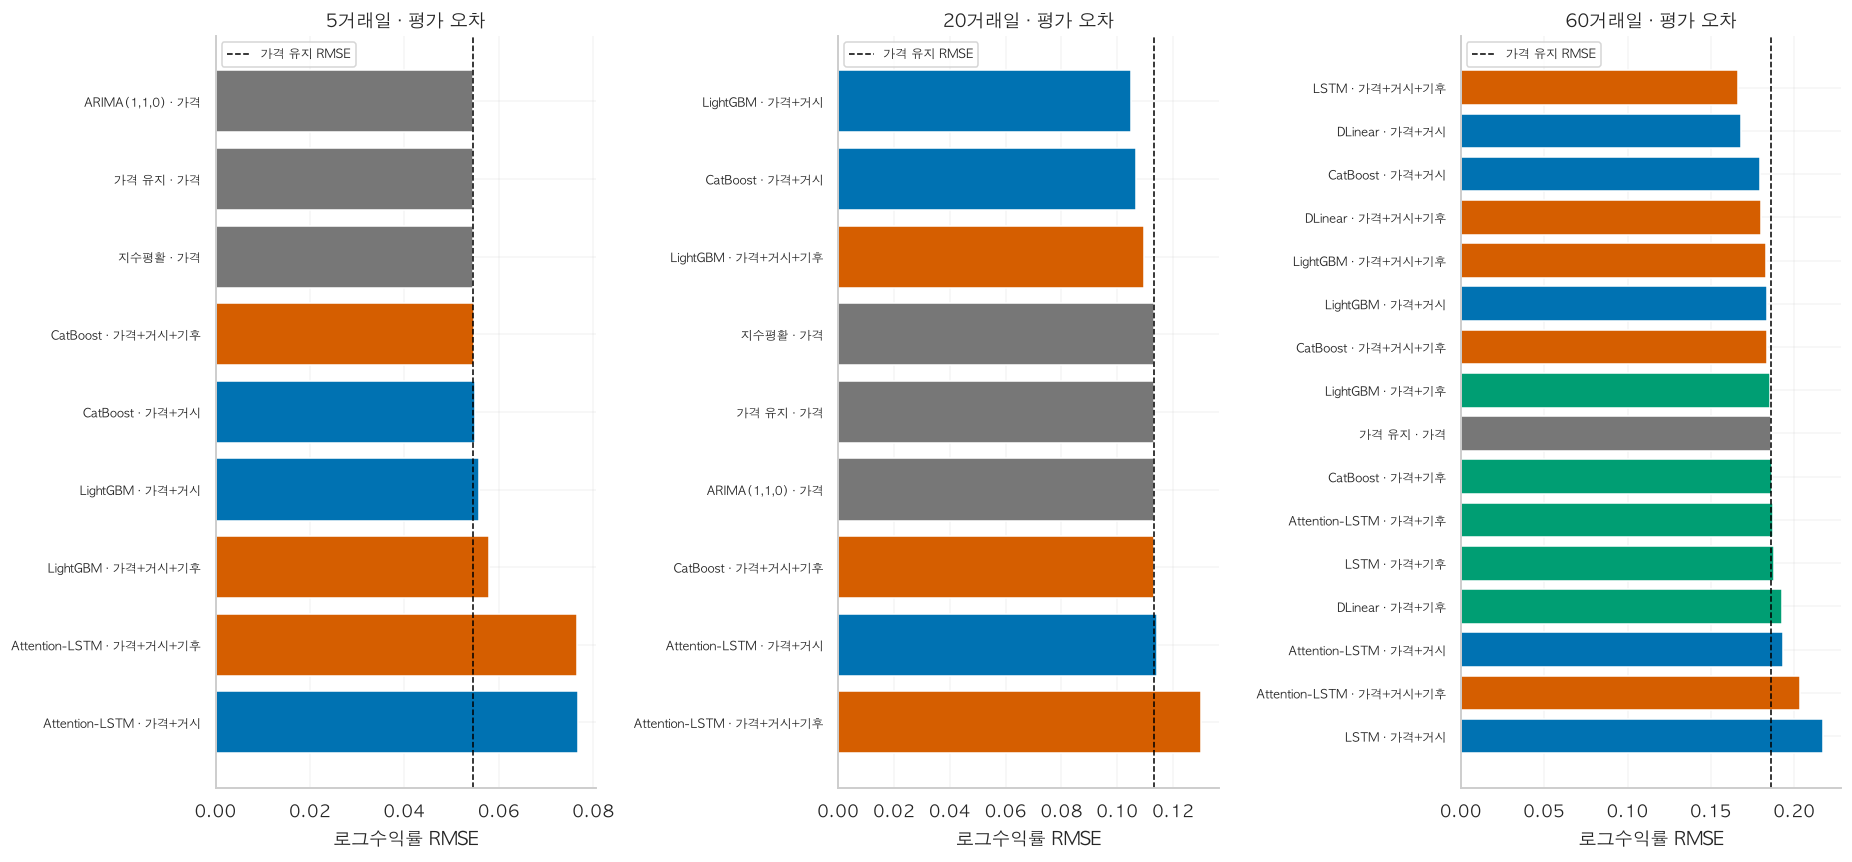

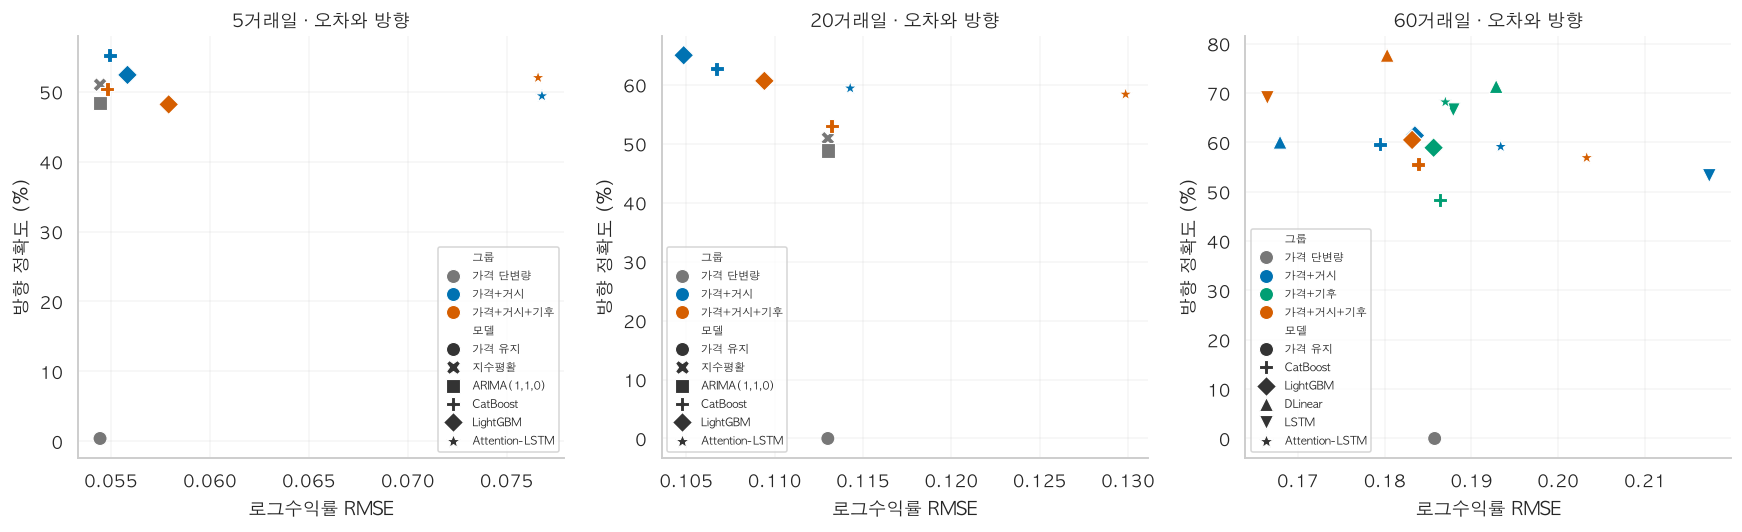

In [11]:
# 모든 후보를 같은 그림에 놓되, 선으로 연결해 시계열처럼 보이게 하지 않는다.
GROUP_COLORS = {"가격 단변량": "#777777", "가격+거시": "#0072B2",
                "가격+기후": "#009E73", "가격+거시+기후": "#D55E00"}
fig, axes = plt.subplots(1, 3, figsize=(17, 8))
for ax, h in zip(axes, HORIZONS):
    rows = test_scores.query("지평 == @h").sort_values("RMSE")
    labels = rows["모델"] + " · " + rows["그룹"].replace({"가격 단변량": "가격"})
    ax.barh(labels, rows.RMSE, color=[GROUP_COLORS[g] for g in rows["그룹"]])
    naive = rows.loc[rows["모델"].eq("가격 유지"), "RMSE"].iloc[0]
    ax.axvline(naive, color="black", linestyle="--", linewidth=1, label="가격 유지 RMSE")
    ax.invert_yaxis()
    ax.set(title=f"{h}거래일 · 평가 오차", xlabel="로그수익률 RMSE")
    ax.tick_params(axis="y", labelsize=8)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, h in zip(axes, HORIZONS):
    sns.scatterplot(data=test_scores.query("지평 == @h"), x="RMSE", y="방향 정확도 (%)",
                    hue="그룹", style="모델", palette=GROUP_COLORS,
                    markers={"가격 유지": "o", "지수평활": "X", "ARIMA(1,1,0)": "s",
                             "CatBoost": "P", "LightGBM": "D", "DLinear": "^",
                             "LSTM": "v", "Attention-LSTM": "*"}, s=85, ax=ax)
    ax.set(title=f"{h}거래일 · 오차와 방향", xlabel="로그수익률 RMSE", ylabel="방향 정확도 (%)")
    ax.legend(fontsize=7, loc="best")
fig.tight_layout()
plt.show()

# 5. 피처 추가와 Attention이 도움이 됐을까?

같은 모델 안에서 전체−부분 그룹의 차이를 읽는다. `ΔRMSE`가 음수면 추가 후 오차가 줄었다.
각 조합의 설정도 Validation에서 선택했으므로, 차이를 피처 하나만의 순수 효과로 해석하지 않는다.
Attention과 일반 LSTM의 직접 대조는 둘 다 비교한 **60일 지평**에서 한다.

In [12]:
effects = []
for split, scores in [("Validation", validation_scores), ("Test", test_scores)]:
    for h in HORIZONS:
        rows = scores.query("지평 == @h")
        for family in rows["모델"].unique():
            subset = rows.loc[rows["모델"].eq(family)].set_index("그룹")
            if "가격+거시+기후" not in subset.index:
                continue
            full = subset.loc["가격+거시+기후"]
            for base, addition in [("가격+거시", "기후 추가"), ("가격+기후", "거시 추가")]:
                if base not in subset.index:
                    continue
                other = subset.loc[base]
                effects.append({"구간": split, "지평": h, "모델": family, "비교": addition,
                                "기준 그룹": base, "기준 설정": int(other["설정"]), "전체 설정": int(full["설정"]),
                                "ΔRMSE": full.RMSE-other.RMSE,
                                "RMSE 개선 (%)": 100*(1-full.RMSE/other.RMSE),
                                "방향 정확도 차이 (%p)": full["방향 정확도 (%)"]-other["방향 정확도 (%)"]})
feature_effects = pd.DataFrame(effects)
for split in ("Validation", "Test"):
    display(Markdown(f"**{split} · 그룹 추가 효과**"))
    show_table(feature_effects.query("구간 == @split"))

attention_rows = []
for split, scores in [("Validation", validation_scores), ("Test", test_scores)]:
    for group in GROUP_COLUMNS:
        rows = scores.loc[(scores["지평"] == 60) & scores["그룹"].eq(group)].set_index("모델")
        plain, attention = rows.loc["LSTM"], rows.loc["Attention-LSTM"]
        attention_rows.append({"구간": split, "그룹": group, "LSTM RMSE": plain.RMSE,
                               "Attention-LSTM RMSE": attention.RMSE,
                               "RMSE 개선 (%)": 100*(1-attention.RMSE/plain.RMSE),
                               "LSTM epoch": int(plain["설정"]), "Attention epoch": int(attention["설정"])})
attention_comparison = pd.DataFrame(attention_rows)
show_table(attention_comparison)

**Validation · 그룹 추가 효과**

| 구간   |   지평 | 모델           | 비교      | 기준 그룹   |   기준 설정 |   전체 설정 |    ΔRMSE |   RMSE 개선 (%) |   방향 정확도 차이 (%p) |
|:-------|-------:|:---------------|:----------|:------------|------------:|------------:|---------:|----------------:|------------------------:|
| 검증   |      5 | CatBoost       | 기후 추가 | 가격+거시   |         150 |         150 |  0.00006 |        -0.12458 |                 0.40323 |
| 검증   |      5 | LightGBM       | 기후 추가 | 가격+거시   |         150 |         150 |  0.00075 |        -1.51601 |                -1.81452 |
| 검증   |      5 | Attention-LSTM | 기후 추가 | 가격+거시   |         100 |         100 | -0.01913 |        24.22926 |                -0.40323 |
| 검증   |     20 | CatBoost       | 기후 추가 | 가격+거시   |         150 |         150 | -0.00645 |         6.59755 |                16.42412 |
| 검증   |     20 | LightGBM       | 기후 추가 | 가격+거시   |         150 |         150 | -0.00632 |         6.19738 |                11.85031 |
| 검증   |     20 | Attention-LSTM | 기후 추가 | 가격+거시   |         100 |         100 | -0.01885 |        14.47331 |                -7.69231 |
| 검증   |     60 | CatBoost       | 기후 추가 | 가격+거시   |         150 |         150 | -0.01637 |         9.65388 |                 5.44218 |
| 검증   |     60 | CatBoost       | 거시 추가 | 가격+기후   |         150 |         150 | -0.00453 |         2.87251 |                 1.58730 |
| 검증   |     60 | LightGBM       | 기후 추가 | 가격+거시   |         150 |         150 | -0.02310 |        13.31258 |                 9.07029 |
| 검증   |     60 | LightGBM       | 거시 추가 | 가격+기후   |         150 |         150 | -0.00680 |         4.32372 |                 0.22676 |
| 검증   |     60 | DLinear        | 기후 추가 | 가격+거시   |          50 |          50 |  0.04488 |       -30.48807 |                 0.68027 |
| 검증   |     60 | DLinear        | 거시 추가 | 가격+기후   |         100 |          50 | -0.01359 |         6.60998 |                 7.48299 |
| 검증   |     60 | LSTM           | 기후 추가 | 가격+거시   |         100 |         100 |  0.00471 |        -2.90910 |                -3.62812 |
| 검증   |     60 | LSTM           | 거시 추가 | 가격+기후   |          50 |         100 | -0.01629 |         8.91502 |                 8.16327 |
| 검증   |     60 | Attention-LSTM | 기후 추가 | 가격+거시   |         100 |         100 |  0.00177 |        -1.14180 |                 9.07029 |
| 검증   |     60 | Attention-LSTM | 거시 추가 | 가격+기후   |         100 |         100 | -0.02083 |        11.70078 |                 6.57596 |

**Test · 그룹 추가 효과**

| 구간   |   지평 | 모델           | 비교      | 기준 그룹   |   기준 설정 |   전체 설정 |    ΔRMSE |   RMSE 개선 (%) |   방향 정확도 차이 (%p) |
|:-------|-------:|:---------------|:----------|:------------|------------:|------------:|---------:|----------------:|------------------------:|
| 평가   |      5 | CatBoost       | 기후 추가 | 가격+거시   |         150 |         150 | -0.00013 |         0.24006 |                -4.81928 |
| 평가   |      5 | LightGBM       | 기후 추가 | 가격+거시   |         150 |         150 |  0.00208 |        -3.73384 |                -4.21687 |
| 평가   |      5 | Attention-LSTM | 기후 추가 | 가격+거시   |         100 |         100 | -0.00020 |         0.25576 |                 2.61044 |
| 평가   |     20 | CatBoost       | 기후 추가 | 가격+거시   |         150 |         150 |  0.00651 |        -6.10533 |                -9.73085 |
| 평가   |     20 | LightGBM       | 기후 추가 | 가격+거시   |         150 |         150 |  0.00457 |        -4.35703 |                -4.34783 |
| 평가   |     20 | Attention-LSTM | 기후 추가 | 가격+거시   |         100 |         100 |  0.01559 |       -13.64126 |                -1.03520 |
| 평가   |     60 | CatBoost       | 기후 추가 | 가격+거시   |         150 |         150 |  0.00444 |        -2.47551 |                -4.06321 |
| 평가   |     60 | CatBoost       | 거시 추가 | 가격+기후   |         150 |         150 | -0.00249 |         1.33735 |                 7.22348 |
| 평가   |     60 | LightGBM       | 기후 추가 | 가격+거시   |         150 |         150 | -0.00032 |         0.17548 |                -0.90293 |
| 평가   |     60 | LightGBM       | 거시 추가 | 가격+기후   |         150 |         150 | -0.00248 |         1.33387 |                 1.58014 |
| 평가   |     60 | DLinear        | 기후 추가 | 가격+거시   |          50 |          50 |  0.01235 |        -7.35104 |                17.60722 |
| 평가   |     60 | DLinear        | 거시 추가 | 가격+기후   |         100 |          50 | -0.01256 |         6.51416 |                 6.32054 |
| 평가   |     60 | LSTM           | 기후 추가 | 가격+거시   |         100 |         100 | -0.05093 |        23.42704 |                15.80135 |
| 평가   |     60 | LSTM           | 거시 추가 | 가격+기후   |          50 |         100 | -0.02143 |        11.40598 |                 2.48307 |
| 평가   |     60 | Attention-LSTM | 기후 추가 | 가격+거시   |         100 |         100 |  0.00991 |        -5.12725 |                -2.25734 |
| 평가   |     60 | Attention-LSTM | 거시 추가 | 가격+기후   |         100 |         100 |  0.01629 |        -8.71194 |               -11.28668 |

| 구간   | 그룹           |   LSTM RMSE |   Attention-LSTM RMSE |   RMSE 개선 (%) |   LSTM epoch |   Attention epoch |
|:-------|:---------------|------------:|----------------------:|----------------:|-------------:|------------------:|
| 검증   | 가격+거시      |     0.16175 |               0.15543 |         3.91026 |          100 |               100 |
| 검증   | 가격+기후      |     0.18275 |               0.17803 |         2.58097 |           50 |               100 |
| 검증   | 가격+거시+기후 |     0.16646 |               0.15720 |         5.56045 |          100 |               100 |
| 평가   | 가격+거시      |     0.21741 |               0.19337 |        11.05809 |          100 |               100 |
| 평가   | 가격+기후      |     0.18791 |               0.18700 |         0.48845 |           50 |               100 |
| 평가   | 가격+거시+기후 |     0.16648 |               0.20329 |       -22.10863 |          100 |               100 |

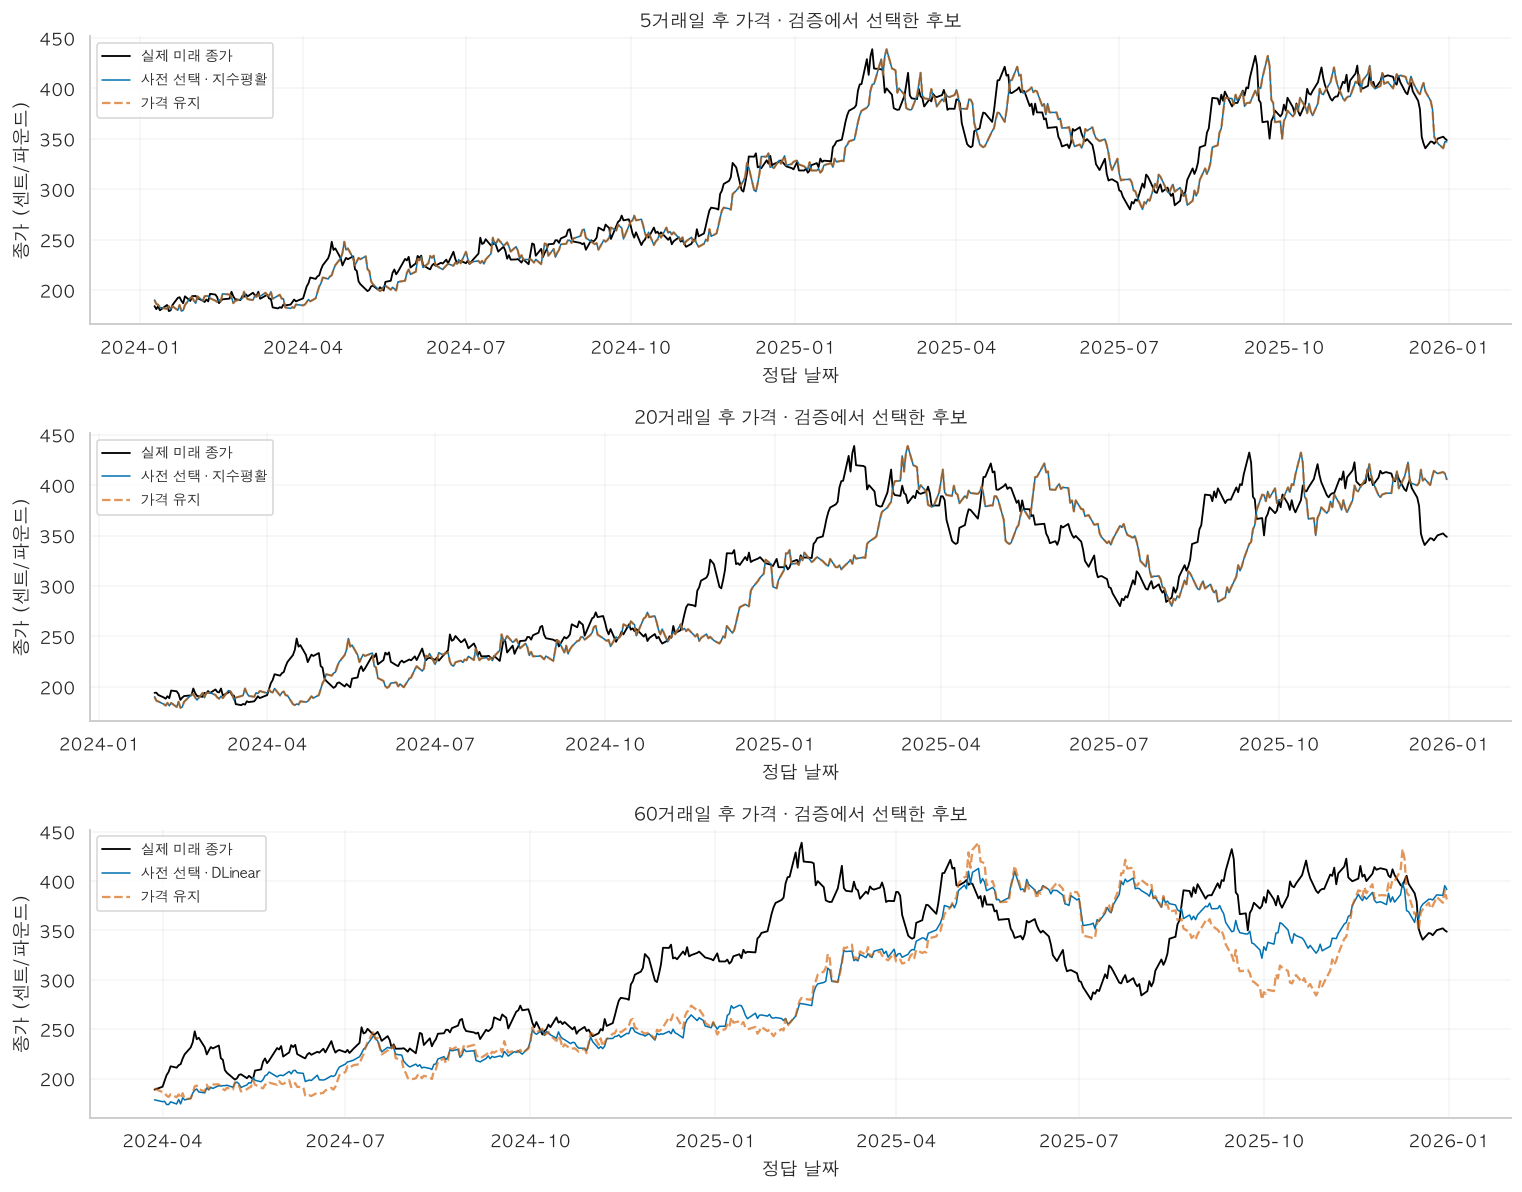

|   지평 | 선택 모델   | 선택 그룹   | 설정   |   검증 RMSE |   평가 RMSE |   검증 Naive 대비 개선 (%) |   평가 Naive 대비 개선 (%) |
|-------:|:------------|:------------|:-------|------------:|------------:|---------------------------:|---------------------------:|
|      5 | 지수평활    | 가격 단변량 | 고정   |     0.04707 |     0.05444 |                    0.00025 |                   -0.00008 |
|     20 | 지수평활    | 가격 단변량 | 고정   |     0.09102 |     0.11300 |                    0.00003 |                    0.00006 |
|     60 | DLinear     | 가격+거시   | 50     |     0.14719 |     0.16794 |                    7.88304 |                    9.59240 |

In [13]:
summary_rows = []
fig, axes = plt.subplots(3, 1, figsize=(14, 11))
for ax, h in zip(axes, HORIZONS):
    key = chosen_candidates[h]
    val = validation_scores.loc[(validation_scores["지평"]==h) & validation_scores["모델"].eq(key[1]) & validation_scores["그룹"].eq(key[2])].iloc[0]
    test = test_scores.loc[(test_scores["지평"]==h) & test_scores["모델"].eq(key[1]) & test_scores["그룹"].eq(key[2])].iloc[0]
    summary_rows.append({"지평": h, "선택 모델": key[1], "선택 그룹": key[2], "설정": val["설정"],
                         "검증 RMSE": val.RMSE, "평가 RMSE": test.RMSE,
                         "검증 Naive 대비 개선 (%)": val["Naive 대비 개선 (%)"],
                         "평가 Naive 대비 개선 (%)": test["Naive 대비 개선 (%)"]})
    indices = FINAL_SPLITS[h]["Test"]
    dates = Y.iloc[indices][f"target_date_{h}"]
    current = prices.iloc[indices].to_numpy()
    actual = current*np.exp(Y.iloc[indices][f"y_{h}"].to_numpy())
    predicted = current*np.exp(test_predictions[key].to_numpy())
    np.testing.assert_allclose(actual, prices.reindex(pd.DatetimeIndex(dates)).to_numpy())
    ax.plot(dates, actual, label="실제 미래 종가", color="black", linewidth=1.2)
    ax.plot(dates, predicted, label=f"사전 선택 · {key[1]}", color="#0072B2", linewidth=1)
    ax.plot(dates, current, label="가격 유지", color="#D55E00", linestyle="--", alpha=.65)
    ax.set(title=f"{h}거래일 후 가격 · 검증에서 선택한 후보", xlabel="정답 날짜", ylabel="종가 (센트/파운드)")
    ax.legend(fontsize=9)
fig.tight_layout()
plt.show()
selection_summary = pd.DataFrame(summary_rows)
show_table(selection_summary)

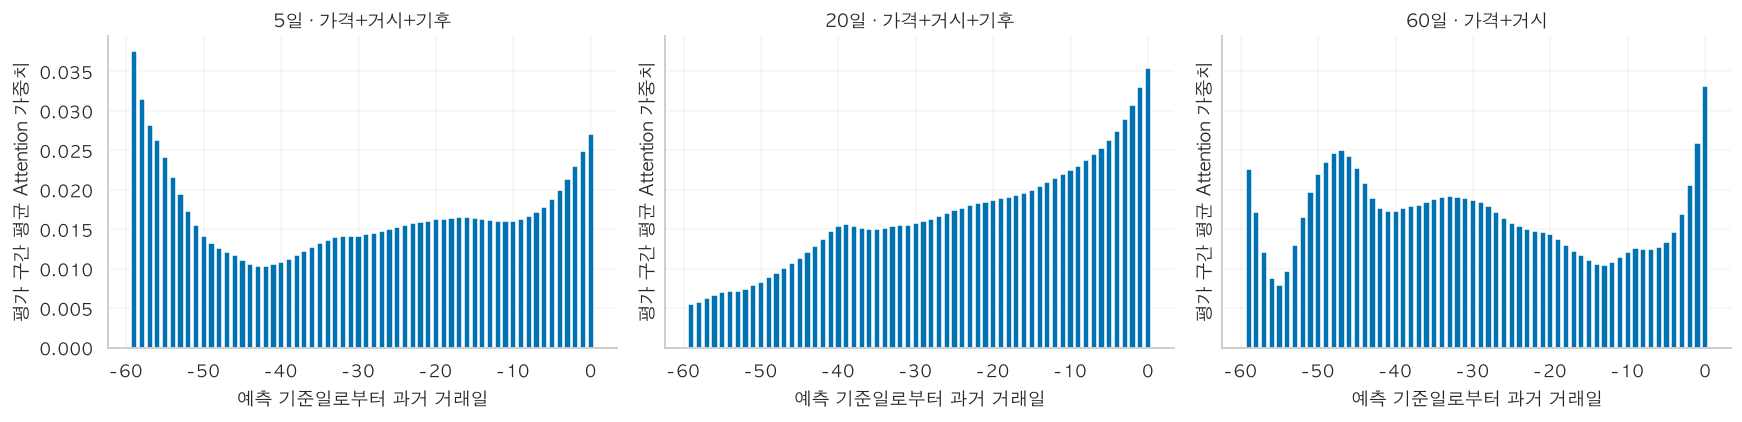

In [14]:
# Attention은 60일의 시간 위치에 대한 가중치다. 기상 변수의 인과적 중요도가 아니다.
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, h in zip(axes, HORIZONS):
    rows = rank_candidates(validation_scores.loc[(validation_scores["지평"]==h) & validation_scores["모델"].eq("Attention-LSTM")])
    group = rows.iloc[0]["그룹"]  # Test 성능으로 시각화 대상을 고르지 않는다.
    bundle = final_models[h, "Attention-LSTM", group]
    values = bundle["scaler"].transform(X_final[bundle["columns"]]).astype("float32")
    windows = torch.from_numpy(make_sequences(values, FINAL_SPLITS[h]["Test"]))
    with torch.no_grad():
        _, weights = bundle["model"](windows, return_attention=True)
    # 60개 float32 가중치의 합산 오차 범위에서 확인한다. 값 자체는 바꾸지 않는다.
    assert torch.isfinite(weights).all() and (weights >= 0).all()
    np.testing.assert_allclose(weights.sum(1).numpy(), 1., rtol=0,
                               atol=LOOKBACK*torch.finfo(weights.dtype).eps)
    ax.bar(np.arange(-LOOKBACK+1, 1), weights.mean(0).numpy(), color="#0072B2")
    ax.set(title=f"{h}일 · {group}", xlabel="예측 기준일로부터 과거 거래일", ylabel="평가 구간 평균 Attention 가중치")
fig.tight_layout()
plt.show()

In [15]:
sensitivity_rows = []
for h in HORIZONS:
    indices = FINAL_SPLITS[h]["Test"]
    masks = {str(year): SESSIONS[indices].year == year for year in (2024, 2025)}
    for offset in (0, h//3, 2*h//3):
        mask = (indices-indices[0]-offset) % h == 0
        selected = indices[mask]
        assert (np.diff(selected) >= h).all()
        assert (Y.iloc[selected[:-1]][f"target_date_{h}"].to_numpy() <= SESSIONS[selected[1:]].to_numpy()).all()
        masks[f"비중첩 시작 {offset}"] = mask
    for key, pred in test_predictions.items():
        if key[0] != h:
            continue
        for label, mask in masks.items():
            sensitivity_rows.append({"지평": h, "모델": key[1], "그룹": key[2], "확인 구간": label,
                                     "표본": int(mask.sum()), **metrics(Y.iloc[indices[mask]][f"y_{h}"], pred.iloc[np.flatnonzero(mask)])})
sensitivity_scores = pd.DataFrame(sensitivity_rows)
selected_sensitivity = pd.DataFrame([row for row in sensitivity_rows
    if (row["지평"], row["모델"], row["그룹"]) == chosen_candidates[row["지평"]]])
display(Markdown("**사전 선택 후보의 연도별·비중첩 확인**"))
show_table(selected_sensitivity)

for row in selection_summary.to_dict("records"):
    display(Markdown(f"- **{row['지평']}일**: Validation 선택은 **{row['선택 모델']} / {row['선택 그룹']}**. "
                     f"Naive 대비 RMSE 개선은 검증 {row['검증 Naive 대비 개선 (%)']:+.5f}%, "
                     f"Test {row['평가 Naive 대비 개선 (%)']:+.5f}%다."))
display(Markdown("방향 정확도는 수익률 부호를 비교하고 0은 보합으로 처리한다. Naive를 50% 기준선으로 읽지 않는다. "
                 "작은 RMSE 차이만으로 우월성을 확정하지 않으며, 이미 본 Test·단일 seed·중첩 타깃이라는 한계를 유지한다. "
                 "비중첩의 세 시작점은 같은 시계열을 다시 뽑은 것으로 독립 표본 수를 합산하지 않는다. "
                 "이번에는 서빙 검토 후보까지 정리하며 FastAPI 구현은 다음 단계로 남긴다."))

**사전 선택 후보의 연도별·비중첩 확인**

|   지평 | 모델     | 그룹        | 확인 구간      |   표본 |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |
|-------:|:---------|:------------|:---------------|-------:|--------:|--------:|------------------:|----------------------:|
|      5 | 지수평활 | 가격 단변량 | 2024           |    252 | 0.04872 | 0.03802 |          54.76190 |               0.00022 |
|      5 | 지수평활 | 가격 단변량 | 2025           |    246 | 0.05974 | 0.04771 |          47.15447 |              -0.00029 |
|      5 | 지수평활 | 가격 단변량 | 비중첩 시작 0  |    100 | 0.05255 | 0.04224 |          48.00000 |              -0.00051 |
|      5 | 지수평활 | 가격 단변량 | 비중첩 시작 1  |    100 | 0.05466 | 0.04297 |          50.00000 |               0.00048 |
|      5 | 지수평활 | 가격 단변량 | 비중첩 시작 3  |     99 | 0.05824 | 0.04537 |          52.52525 |               0.00028 |
|     20 | 지수평활 | 가격 단변량 | 2024           |    252 | 0.09932 | 0.07295 |          53.57143 |               0.00018 |
|     20 | 지수평활 | 가격 단변량 | 2025           |    231 | 0.12626 | 0.09894 |          48.05195 |              -0.00002 |
|     20 | 지수평활 | 가격 단변량 | 비중첩 시작 0  |     25 | 0.12468 | 0.09311 |          52.00000 |               0.00041 |
|     20 | 지수평활 | 가격 단변량 | 비중첩 시작 6  |     24 | 0.09759 | 0.07948 |          58.33333 |               0.00018 |
|     20 | 지수평활 | 가격 단변량 | 비중첩 시작 13 |     24 | 0.13186 | 0.09997 |          45.83333 |               0.00035 |
|     60 | DLinear  | 가격+거시   | 2024           |    252 | 0.18550 | 0.15557 |          52.77778 |               2.94413 |
|     60 | DLinear  | 가격+거시   | 2025           |    191 | 0.14148 | 0.12041 |          69.63351 |              20.71092 |
|     60 | DLinear  | 가격+거시   | 비중첩 시작 0  |      8 | 0.14586 | 0.12441 |          37.50000 |              -6.02434 |
|     60 | DLinear  | 가격+거시   | 비중첩 시작 20 |      8 | 0.13154 | 0.11157 |          62.50000 |              19.55832 |
|     60 | DLinear  | 가격+거시   | 비중첩 시작 40 |      7 | 0.22313 | 0.17753 |          71.42857 |               8.42544 |

- **5일**: Validation 선택은 **지수평활 / 가격 단변량**. Naive 대비 RMSE 개선은 검증 +0.00025%, Test -0.00008%다.

- **20일**: Validation 선택은 **지수평활 / 가격 단변량**. Naive 대비 RMSE 개선은 검증 +0.00003%, Test +0.00006%다.

- **60일**: Validation 선택은 **DLinear / 가격+거시**. Naive 대비 RMSE 개선은 검증 +7.88304%, Test +9.59240%다.

방향 정확도는 수익률 부호를 비교하고 0은 보합으로 처리한다. Naive를 50% 기준선으로 읽지 않는다. 작은 RMSE 차이만으로 우월성을 확정하지 않으며, 이미 본 Test·단일 seed·중첩 타깃이라는 한계를 유지한다. 비중첩의 세 시작점은 같은 시계열을 다시 뽑은 것으로 독립 표본 수를 합산하지 않는다. 이번에는 서빙 검토 후보까지 정리하며 FastAPI 구현은 다음 단계로 남긴다.

**실행 확인**

검증은 날짜·피처·예측을 직접 확인한다. 별도 실행 로그나 보고서는 만들지 않는다.
참고: [학부 Attention-LSTM](old_code/model_code/Attention_LSTM_모델학습_예측결과활용.ipynb),
[Entmax 원 구현](https://github.com/deep-spin/entmax).

In [16]:
# 날짜를 지운 다음 shift/sequence를 만들면 아래 검사에서 어긋난다.
toy_dates = pd.bdate_range("2020-01-01", periods=180)
toy = pd.Series(100 + np.arange(180, dtype=float), index=toy_dates)
toy.iloc[20] = np.nan
toy_y = make_targets(toy)
for h in HORIZONS:
    assert toy_y[f"target_date_{h}"].iloc[10] == toy_dates[10+h]
    np.testing.assert_allclose(toy_y[f"y_{h}"].iloc[10], np.log(toy.iloc[10+h]/toy.iloc[10]))
    assert pd.isna(toy_y[f"y_{h}"].iloc[20])
    if 20-h >= 0:
        assert pd.isna(toy_y[f"y_{h}"].iloc[20-h])
windows = make_sequences(np.arange(360).reshape(180, 2), np.array([59, 90]))
np.testing.assert_array_equal(windows[1], np.arange(360).reshape(180, 2)[31:91])
np.testing.assert_array_equal(windows[:, -1, 0], [118, 180])

for cutoff in (TRAIN_END, VAL_END):
    changed = {k: v.copy(deep=True) for k, v in sources.items()}
    for frame in changed.values():
        numeric = frame.select_dtypes(include="number").columns
        frame[numeric] = frame[numeric].astype(float)
        frame.loc[frame.date > cutoff, numeric] = frame.loc[frame.date > cutoff, numeric]*1.1+.01
        if "release_date" in frame:
            mask = pd.to_datetime(frame.release_date)+pd.Timedelta(days=1) > cutoff
            frame.loc[mask, "value"] += 99
    before, _, before_availability, _ = build_features(sources, cutoff)
    after, _, _, _ = build_features(changed, cutoff)
    pd.testing.assert_frame_equal(before.loc[:cutoff], after.loc[:cutoff])
    new_y = make_targets(changed["coffee"].set_index("date").close.reindex(SESSIONS))
    for h in HORIZONS:
        old_rows = eligible_rows(before, Y, h, TRAIN_START, cutoff)
        new_rows = eligible_rows(after, new_y, h, TRAIN_START, cutoff)
        np.testing.assert_array_equal(old_rows, new_rows)
        pd.testing.assert_series_equal(Y.iloc[old_rows][f"y_{h}"], new_y.iloc[new_rows][f"y_{h}"])
        # 학습에 전달하는 값·순서·표준화 통계가 미래 자료 변경에도 그대로인지 확인한다.
        np.testing.assert_array_equal(make_sequences(before[FEATURES].to_numpy(), old_rows),
                                      make_sequences(after[FEATURES].to_numpy(), new_rows))
        a = StandardScaler().fit(before.iloc[old_rows][FEATURES])
        b = StandardScaler().fit(after.iloc[new_rows][FEATURES])
        np.testing.assert_array_equal(a.mean_, b.mean_)
        np.testing.assert_array_equal(a.scale_, b.scale_)
    for info in before_availability.values():
        valid = info.available_at.notna()
        assert (info.loc[valid, "available_at"] <= info.index[valid]).all()

for split, scores, predictions, features in [
    ("Validation", validation_scores, validation_predictions, X),
    ("Test", test_scores, test_predictions, X_final)]:
    for row in scores.to_dict("records"):
        h, key = row["지평"], (row["지평"], row["모델"], row["그룹"])
        indices = SPLITS[h][split]
        np.testing.assert_array_equal(predictions[key].index, indices)
        make_sequences(features[FEATURES].to_numpy(), indices)
        actual = metrics(Y.iloc[indices][f"y_{h}"], predictions[key])
        for metric, value in actual.items():
            np.testing.assert_allclose(row[metric], value, rtol=1e-12, atol=1e-12)
assert (chosen_candidates, chosen_settings) == frozen_selection

# 고정 모수 상태 갱신은 전체 이력을 같은 모수로 필터링한 결과와 같아야 한다.
example = pd.Series(np.log(10+np.arange(80)*.03+np.sin(np.arange(80))*.1))
for kind in ("ses", "arima"):
    model = PriceForecaster(kind).fit(example.iloc[:60], fh=[5, 20])
    old_forecast = model.predict(fh=[5, 20]).to_numpy()
    params = model.result_.params.copy()
    observations = example.iloc[60:65]+.1
    model.update(observations, update_params=False)
    np.testing.assert_array_equal(params, model.result_.params)
    assert int(model.cutoff[0]) == 64
    assert not np.allclose(model.predict(fh=[5, 20]), old_forecast)
    history = pd.concat([example.iloc[:60], observations])
    reference = model.result_.model.clone(history).filter(params).forecast(20)
    np.testing.assert_allclose(model.predict(fh=[5, 20]), np.asarray(reference)[[4, 19]], atol=1e-8)
print("검증 완료: 거래일·시퀀스·미래 변경 불변성·공통 행·표 지표·상태 갱신·선택 고정")

검증 완료: 거래일·시퀀스·미래 변경 불변성·공통 행·표 지표·상태 갱신·선택 고정


**이번 비교에서 남긴 점 (50·100 epoch)**

5·20일에서 선택된 지수평활은 가격 유지와 사실상 같았다. 20일 가격+거시 LightGBM은 Test RMSE가 가장 낮았지만, Validation에서는 Naive보다 나빴으므로 선택 모델을 바꾸지 않았다.

60일은 **가격+거시 DLinear, 50 epoch**를 서빙 검토 후보로 남긴다. Naive 대비 RMSE가 Validation 7.88%, Test 9.59% 줄었다. 이전 30·60 epoch 비교의 7.76%·9.63%와 거의 같아, 학습량을 늘린 효과는 작았다. 예측 기준일 연도별 Test 개선율은 2024년 2.94%, 2025년 20.71%다. 비중첩 시작점에 따라 -6.02~+19.56%로 달랐고 표본은 7~8개뿐이므로 안정적인 우위를 확정하지 않는다.

기후를 더 넣는 효과는 모델과 기간에 따라 달랐다. 20일 CatBoost·LightGBM은 기후 추가 후 Validation 오차가 줄었지만 Test에서는 늘었다. 60일 DLinear에 기후를 추가하면 Test 방향 정확도는 17.61%p 높아졌지만 RMSE는 Validation 30.49%, Test 7.35% 늘었다. 이번에는 RMSE를 우선하기로 한 선택 기준을 유지한다.

60일 Attention-LSTM은 일반 LSTM보다 세 그룹 모두 Validation RMSE가 낮았다. Test에서는 가격+거시·가격+기후가 각각 11.06%·0.49% 개선됐지만, 전체 피처는 22.11% 악화됐다. 세 그룹 모두 Test에서 Naive를 넘지 못했다. 전체 피처 일반 LSTM(100 epoch)은 Test RMSE가 0.16648로 가장 낮아도 Validation에서는 Naive보다 4.17% 나빴으므로 사전 선택을 유지한다. 조합별 epoch 선택을 포함한 비교이며, 이번 설정에서도 Attention의 일관된 이점을 확인하지 못했다.

# 6. 방향 정확도로 후보를 거른 뒤 50:50으로 섞기

앞의 개별 모델 비교와 선택 결과는 유지한다. 여기서는 다른 선택 규칙을 별도 실험으로 확인한다.

- **Validation 방향 정확도 50% 이상**인 후보 중 로그수익률 RMSE가 낮은 두 개를 고른다.
- 후보 단위는 **모델 + 피처 그룹**이다. 같은 CatBoost라도 입력 그룹이 다르면 별도 후보로 취급한다.
- 각 후보의 트리 수·epoch는 앞에서 Validation RMSE로 고른 설정을 그대로 쓴다. 동률 처리도 기존 규칙을 따른다.
- 두 예측 로그수익률을 정확히 반씩 섞고 `현재 종가 × exp(평균 예측 수익률)`로 가격을 환산한다.
- 구성원과 50:50 가중치는 Validation에서 확정한다. Test에서 조합을 바꾸지 않는다.

50%는 후보 필터이지 통계적 우월성의 증명은 아니다. 상승·하락 비율과 중첩 수익률 때문에
항상 상승·항상 하락 기준도 함께 확인한다. 구성원들이 50%를 넘었다고 앙상블도 넘는 것은 아니다.
이미 확인한 Test를 사용하는 추가 실험이며, 아래 Validation 성능도 후보 선택에 사용된 값이다.
가중치 탐색·부호/크기 결합·임계치 스위칭은 이번 비교에 포함하지 않는다.

In [17]:
def choose_ensemble_members(scores, h):
    eligible = scores.loc[(scores["지평"] == h) & scores["방향 정확도 (%)"].ge(50)]
    if len(eligible) < 2:
        raise ValueError(f"{h}일: 방향 정확도 조건을 만족하는 후보가 두 개 미만입니다.")
    return rank_candidates(eligible).head(2).copy()


ensemble_members, member_rows = {}, []
for h in HORIZONS:
    members = choose_ensemble_members(validation_scores, h)
    ensemble_members[h] = tuple((h, row["모델"], row["그룹"]) for row in members.to_dict("records"))
    for order, row in enumerate(members.to_dict("records"), 1):
        member_rows.append({"지평": h, "구성": order, "모델": row["모델"], "그룹": row["그룹"],
                            "설정": row["설정"], "검증 RMSE": row["RMSE"],
                            "검증 방향 정확도 (%)": row["방향 정확도 (%)"], "가중치": .5})
ensemble_selection = pd.DataFrame(member_rows)
frozen_ensemble_members = ensemble_members.copy()
show_table(ensemble_selection)

# 오차가 가장 작아도 방향 조건에 미달하면 선택하지 않는다. 정확히 50%는 포함한다.
fixture = pd.DataFrame({"지평": [5]*3, "모델": ["제외", "경계", "통과"], "그룹": ["예제"]*3,
                        "설정": [1]*3, "피처 수": [1]*3, "RMSE": [.01, .03, .02],
                        "방향 정확도 (%)": [49.9, 50., 55.]})
assert choose_ensemble_members(fixture, 5)["모델"].tolist() == ["통과", "경계"]
try:
    choose_ensemble_members(fixture.iloc[:1], 5)
except ValueError:
    pass
else:
    raise AssertionError("후보 부족을 확인해야 합니다.")

|   지평 |   구성 | 모델         | 그룹           | 설정   |   검증 RMSE |   검증 방향 정확도 (%) |   가중치 |
|-------:|-------:|:-------------|:---------------|:-------|------------:|-----------------------:|---------:|
|      5 |      1 | CatBoost     | 가격+거시      | 150    |     0.04770 |               50.80645 |  0.50000 |
|      5 |      2 | CatBoost     | 가격+거시+기후 | 150    |     0.04776 |               51.20968 |  0.50000 |
|     20 |      1 | ARIMA(1,1,0) | 가격 단변량    | 고정   |     0.09102 |               50.51975 |  0.50000 |
|     20 |      2 | CatBoost     | 가격+거시+기후 | 150    |     0.09126 |               58.00416 |  0.50000 |
|     60 |      1 | DLinear      | 가격+거시      | 50     |     0.14719 |               57.14286 |  0.50000 |
|     60 |      2 | LightGBM     | 가격+거시+기후 | 150    |     0.15041 |               52.60771 |  0.50000 |

In [18]:
def ensemble_metrics(h, indices, prediction):
    actual = Y.iloc[indices][f"y_{h}"]
    result = metrics(actual, prediction)
    current = prices.iloc[indices].to_numpy()
    actual_price = current*np.exp(actual.to_numpy())
    predicted_price = current*np.exp(np.asarray(prediction))
    result.update({"가격 RMSE": root_mean_squared_error(actual_price, predicted_price),
                   "가격 MAE": mean_absolute_error(actual_price, predicted_price)})
    return result


ensemble_predictions, ensemble_comparisons, ensemble_rows, direction_rows = {}, {}, [], []
for split, predictions in [("Validation", validation_predictions), ("Test", test_predictions)]:
    for h in HORIZONS:
        indices = SPLITS[h][split]
        keys = ensemble_members[h]
        first, second = (predictions[key] for key in keys)
        np.testing.assert_array_equal(first.index, indices)
        np.testing.assert_array_equal(second.index, indices)
        average = (first + second)/2
        assert average.notna().all()
        ensemble_predictions[split, h] = average
        comparison = {"가격 유지": pd.Series(0., index=indices)}
        if chosen_candidates[h] not in keys:
            comparison[f"기존 선택 · {chosen_candidates[h][1]}"] = predictions[chosen_candidates[h]]
        for order, key in enumerate(keys, 1):
            comparison[f"구성 {order} · {key[1]} / {key[2]}"] = predictions[key]
        comparison["50:50 앙상블"] = average
        ensemble_comparisons[split, h] = comparison
        for label, prediction in comparison.items():
            ensemble_rows.append({"구간": split, "지평": h, "예측": label, "표본": len(indices),
                                  **ensemble_metrics(h, indices, prediction)})
        actual = Y.iloc[indices][f"y_{h}"].to_numpy()
        direction_rows.append({"구간": split, "지평": h,
                               "항상 상승 정확도 (%)": 100*np.mean(actual > 0),
                               "항상 하락 정확도 (%)": 100*np.mean(actual < 0),
                               "보합 비율 (%)": 100*np.mean(actual == 0)})
ensemble_scores = pd.DataFrame(ensemble_rows)
for h in HORIZONS:
    for split in ("Validation", "Test"):
        display(Markdown(f"**{h}거래일 · {'검증' if split == 'Validation' else '평가'} · 단독 모델과 앙상블**"))
        show_table(ensemble_scores.query("지평 == @h and 구간 == @split").drop(columns=["구간", "지평"]))
display(Markdown("RMSE·MAE는 로그수익률 기준, 가격 RMSE·MAE는 센트/파운드 단위다. 가격 단위 지표로 재선택하지 않는다."))
show_table(pd.DataFrame(direction_rows))

**5거래일 · 검증 · 단독 모델과 앙상블**

| 예측                               |   표본 |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |   가격 RMSE |   가격 MAE |
|:-----------------------------------|-------:|--------:|--------:|------------------:|----------------------:|------------:|-----------:|
| 가격 유지                          |    496 | 0.04707 | 0.03775 |           0.20161 |               0.00000 |     9.03104 |    7.21159 |
| 기존 선택 · 지수평활               |    496 | 0.04707 | 0.03775 |          49.39516 |               0.00025 |     9.03101 |    7.21156 |
| 구성 1 · CatBoost / 가격+거시      |    496 | 0.04770 | 0.03822 |          50.80645 |              -1.34877 |     9.15598 |    7.30438 |
| 구성 2 · CatBoost / 가격+거시+기후 |    496 | 0.04776 | 0.03807 |          51.20968 |              -1.47503 |     9.12525 |    7.24241 |
| 50:50 앙상블                       |    496 | 0.04750 | 0.03794 |          50.00000 |              -0.91916 |     9.08967 |    7.23000 |

**5거래일 · 평가 · 단독 모델과 앙상블**

| 예측                               |   표본 |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |   가격 RMSE |   가격 MAE |
|:-----------------------------------|-------:|--------:|--------:|------------------:|----------------------:|------------:|-----------:|
| 가격 유지                          |    498 | 0.05444 | 0.04281 |           0.40161 |               0.00000 |    17.57075 |   13.21556 |
| 기존 선택 · 지수평활               |    498 | 0.05444 | 0.04281 |          51.00402 |              -0.00008 |    17.57076 |   13.21555 |
| 구성 1 · CatBoost / 가격+거시      |    498 | 0.05493 | 0.04341 |          55.22088 |              -0.90330 |    17.75784 |   13.42445 |
| 구성 2 · CatBoost / 가격+거시+기후 |    498 | 0.05480 | 0.04320 |          50.40161 |              -0.66107 |    17.79440 |   13.39569 |
| 50:50 앙상블                       |    498 | 0.05473 | 0.04314 |          51.40562 |              -0.52690 |    17.73506 |   13.35756 |

**20거래일 · 검증 · 단독 모델과 앙상블**

...

| 예측                               |   표본 |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |   가격 RMSE |   가격 MAE |
|:-----------------------------------|-------:|--------:|--------:|------------------:|----------------------:|------------:|-----------:|
| 가격 유지                          |    441 | 0.15979 | 0.12186 |           0.00000 |               0.00000 |    29.50716 |   22.50839 |
| 구성 1 · DLinear / 가격+거시       |    441 | 0.14719 | 0.12605 |          57.14286 |               7.88304 |    29.84508 |   24.60185 |
| 구성 2 · LightGBM / 가격+거시+기후 |    441 | 0.15041 | 0.12607 |          52.60771 |               5.86993 |    27.28122 |   23.08257 |
| 50:50 앙상블                       |    441 | 0.13872 | 0.11900 |          52.38095 |              13.18674 |    25.46038 |   22.03975 |

**60거래일 · 평가 · 단독 모델과 앙상블**

| 예측                               |   표본 |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |   가격 RMSE |   가격 MAE |
|:-----------------------------------|-------:|--------:|--------:|------------------:|----------------------:|------------:|-----------:|
| 가격 유지                          |    443 | 0.18576 | 0.15822 |           0.00000 |               0.00000 |    58.83049 |   48.53251 |
| 구성 1 · DLinear / 가격+거시       |    443 | 0.16794 | 0.14041 |          60.04515 |               9.59240 |    53.04725 |   43.18264 |
| 구성 2 · LightGBM / 가격+거시+기후 |    443 | 0.18317 | 0.15190 |          60.49661 |               1.39783 |    58.51071 |   47.24679 |
| 50:50 앙상블                       |    443 | 0.17236 | 0.14378 |          62.30248 |               7.21465 |    55.05070 |   44.66267 |

RMSE·MAE는 로그수익률 기준, 가격 RMSE·MAE는 센트/파운드 단위다. 가격 단위 지표로 재선택하지 않는다.

| 구간   |   지평 |   항상 상승 정확도 (%) |   항상 하락 정확도 (%) |   보합 비율 (%) |
|:-------|-------:|-----------------------:|-----------------------:|----------------:|
| 검증   |      5 |               45.76613 |               54.03226 |         0.20161 |
| 검증   |     20 |               46.15385 |               53.84615 |         0.00000 |
| 검증   |     60 |               41.04308 |               58.95692 |         0.00000 |
| 평가   |      5 |               54.81928 |               44.77912 |         0.40161 |
| 평가   |     20 |               59.83437 |               40.16563 |         0.00000 |
| 평가   |     60 |               79.00677 |               20.99323 |         0.00000 |

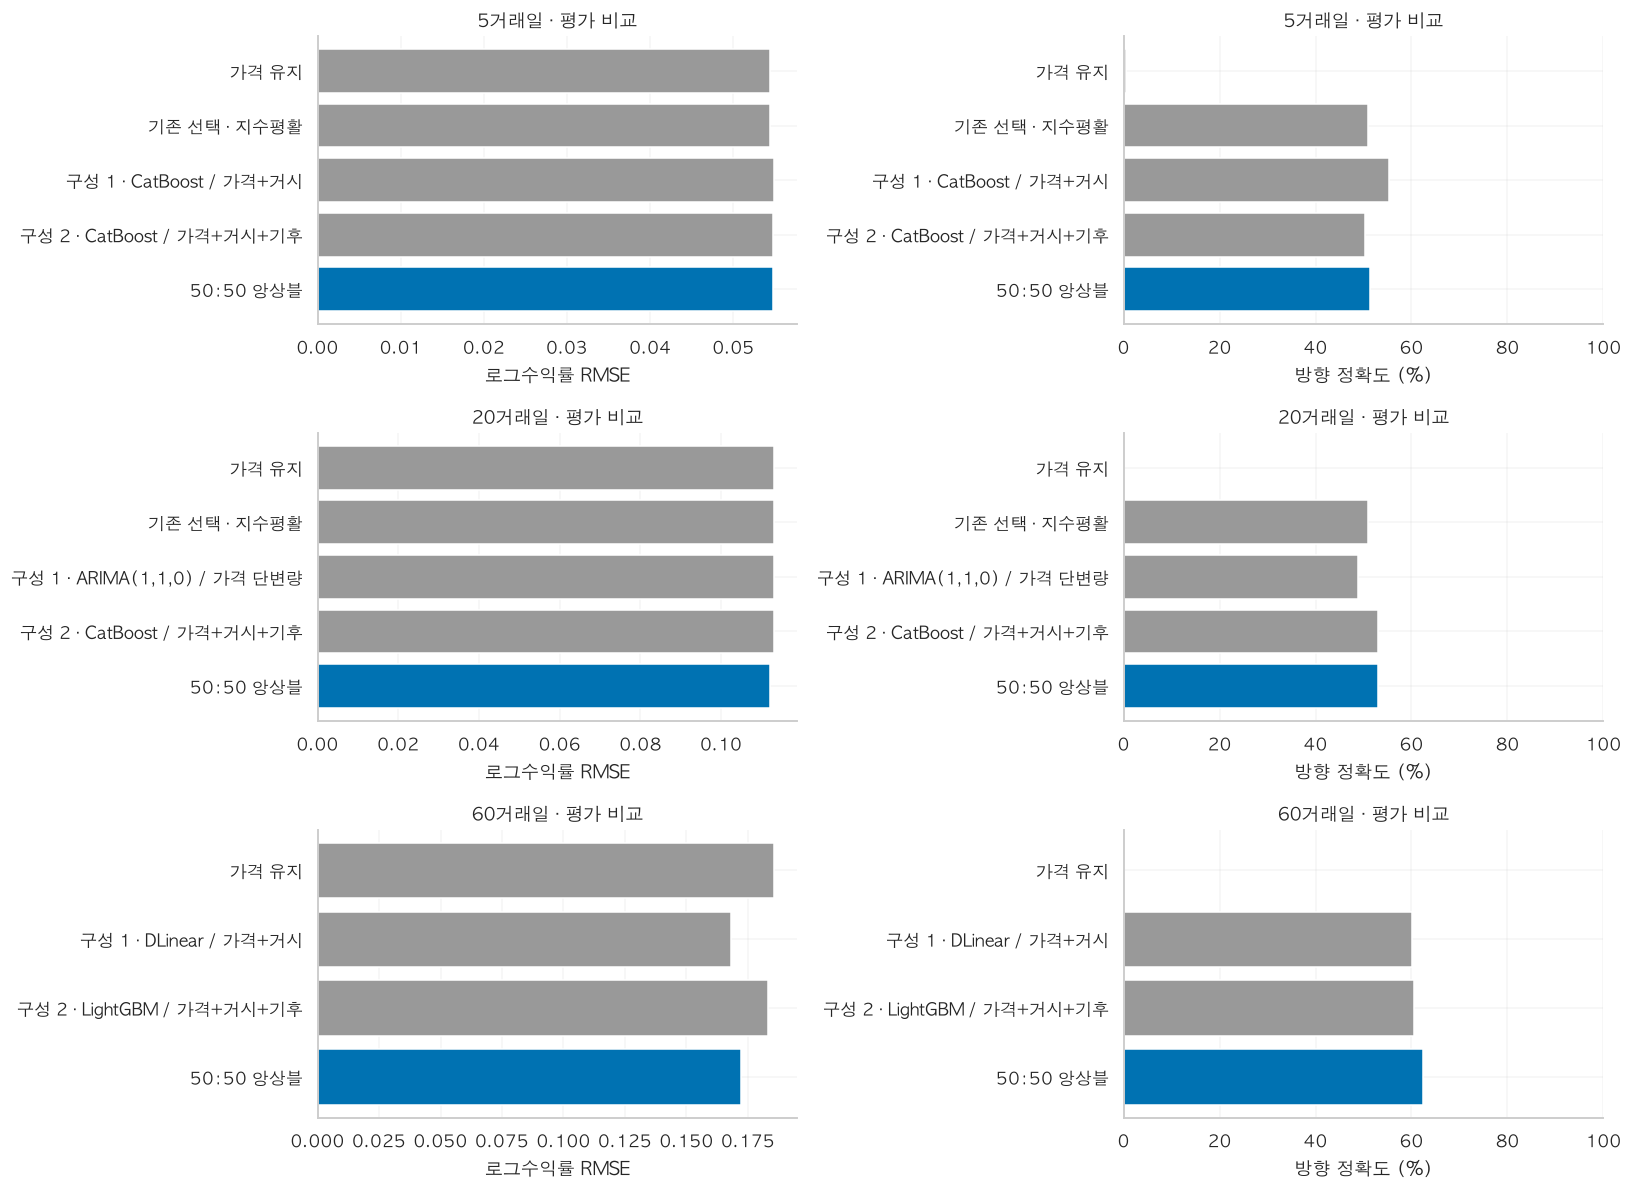

In [19]:
fig, axes = plt.subplots(3, 2, figsize=(15, 11))
for row, h in enumerate(HORIZONS):
    table = ensemble_scores.query("구간 == 'Test' and 지평 == @h")
    colors = ["#0072B2" if label == "50:50 앙상블" else "#999999" for label in table["예측"]]
    for ax, column in zip(axes[row], ("RMSE", "방향 정확도 (%)")):
        ax.barh(table["예측"], table[column], color=colors)
        ax.invert_yaxis()
        ax.set(title=f"{h}거래일 · 평가 비교", xlabel="로그수익률 RMSE" if column == "RMSE" else column)
        if column == "방향 정확도 (%)":
            ax.set_xlim(0, 100)
fig.tight_layout()
plt.show()

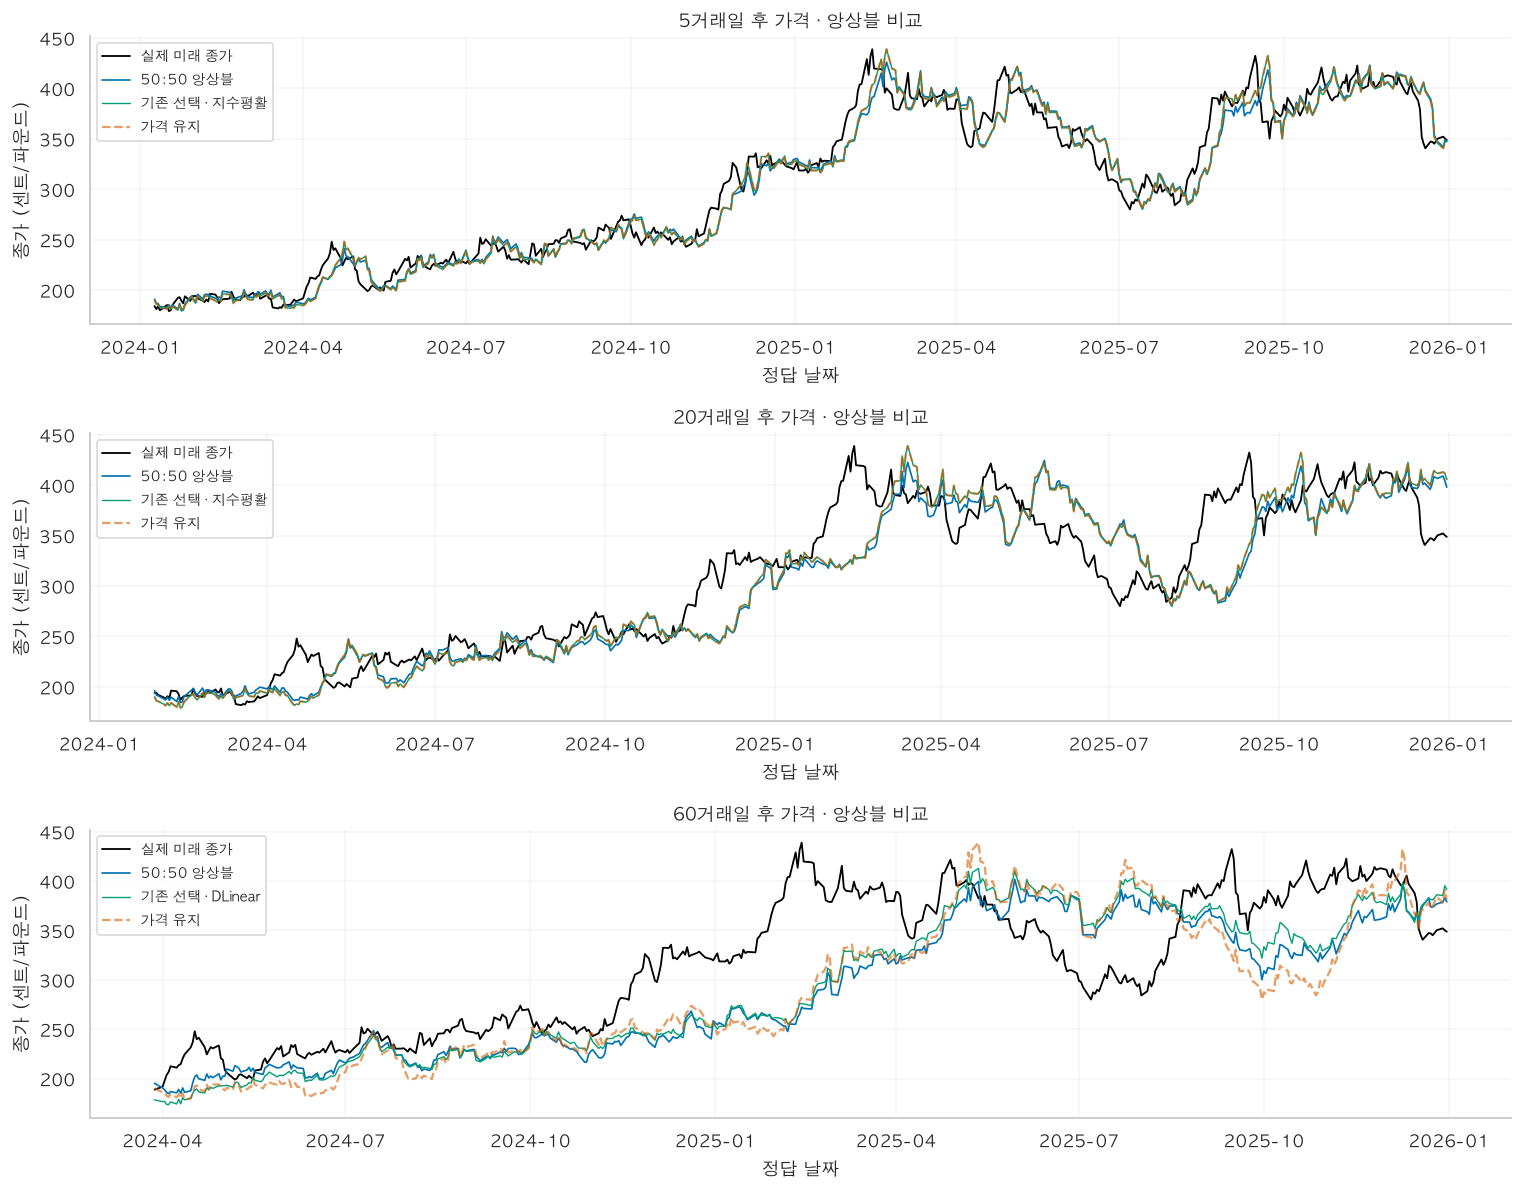

모든 선은 정답 날짜 t+h에 놓았다. 실제 종가를 추가로 이동시키면 서로 다른 시점을 비교하게 된다.

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11))
for ax, h in zip(axes, HORIZONS):
    indices = SPLITS[h]["Test"]
    dates = pd.DatetimeIndex(Y.iloc[indices][f"target_date_{h}"])
    current = prices.iloc[indices].to_numpy()
    actual = current*np.exp(Y.iloc[indices][f"y_{h}"].to_numpy())
    predicted = current*np.exp(ensemble_predictions["Test", h].to_numpy())
    previous = current*np.exp(test_predictions[chosen_candidates[h]].to_numpy())
    np.testing.assert_array_equal(dates, SESSIONS[indices+h])
    np.testing.assert_allclose(actual, prices.reindex(dates).to_numpy())
    ax.plot(dates, actual, color="black", linewidth=1.2, label="실제 미래 종가")
    ax.plot(dates, predicted, color="#0072B2", linewidth=1.1, label="50:50 앙상블")
    ax.plot(dates, previous, color="#009E73", linewidth=.9, label=f"기존 선택 · {chosen_candidates[h][1]}")
    ax.plot(dates, current, color="#D55E00", linestyle="--", alpha=.6, label="가격 유지")
    ax.set(title=f"{h}거래일 후 가격 · 앙상블 비교", xlabel="정답 날짜", ylabel="종가 (센트/파운드)")
    ax.legend(fontsize=9)
fig.tight_layout()
plt.show()
display(Markdown("모든 선은 정답 날짜 t+h에 놓았다. 실제 종가를 추가로 이동시키면 서로 다른 시점을 비교하게 된다."))

In [21]:
ensemble_diagnostics, ensemble_sensitivity = [], []
for h in HORIZONS:
    for split, predictions in [("Validation", validation_predictions), ("Test", test_predictions)]:
        indices = SPLITS[h][split]
        actual = Y.iloc[indices][f"y_{h}"].to_numpy()
        first, second = (predictions[key].to_numpy() for key in ensemble_members[h])
        ensemble_rmse = metrics(actual, ensemble_predictions[split, h])["RMSE"]
        better_member = min(metrics(actual, first)["RMSE"], metrics(actual, second)["RMSE"])
        error_a, error_b = actual-first, actual-second
        correlation = np.corrcoef(error_a, error_b)[0, 1] if min(error_a.std(), error_b.std()) > 0 else np.nan
        ensemble_diagnostics.append({"지평": h, "구간": split, "구성원 오차 상관": correlation,
                                     "낮은 구성원 RMSE": better_member, "앙상블 RMSE": ensemble_rmse,
                                     "구성원 최저 RMSE 대비 개선 (%)": 100*(1-ensemble_rmse/better_member)})
    indices = SPLITS[h]["Test"]
    masks = {str(year): SESSIONS[indices].year == year for year in (2024, 2025)}
    for offset in (0, h//3, 2*h//3):
        mask = (indices-indices[0]-offset) % h == 0
        selected = indices[mask]
        assert (np.diff(selected) >= h).all()
        masks[f"비중첩 시작 {offset}"] = mask
    for label, mask in masks.items():
        actual = Y.iloc[indices[mask]][f"y_{h}"]
        prediction = ensemble_predictions["Test", h].iloc[np.flatnonzero(mask)]
        ensemble_sensitivity.append({"지평": h, "확인 구간": label, "표본": int(mask.sum()),
                                     **metrics(actual, prediction)})
show_table(pd.DataFrame(ensemble_diagnostics))
show_table(pd.DataFrame(ensemble_sensitivity))

# 결과표를 원 예측으로 다시 확인한다. 기존 선택과 예측 배열은 덮어쓰지 않았다.
for row in ensemble_scores.to_dict("records"):
    split, h = row["구간"], row["지평"]
    prediction = ensemble_comparisons[split, h][row["예측"]]
    computed = ensemble_metrics(h, SPLITS[h][split], prediction)
    for metric, value in computed.items():
        np.testing.assert_allclose(row[metric], value, rtol=1e-12, atol=1e-12)
for h in HORIZONS:
    expected_keys = tuple((h, row["모델"], row["그룹"]) for row in
                          choose_ensemble_members(validation_scores, h).to_dict("records"))
    assert ensemble_members[h] == expected_keys
assert ensemble_members == frozen_ensemble_members
assert (chosen_candidates, chosen_settings) == frozen_selection
print("앙상블 검증 완료: 후보 조건·50:50 평균·공통 날짜·가격 환산·표 지표·기존 선택 보존")

|   지평 | 구간   |   구성원 오차 상관 |   낮은 구성원 RMSE |   앙상블 RMSE |   구성원 최저 RMSE 대비 개선 (%) |
|-------:|:-------|-------------------:|-------------------:|--------------:|---------------------------------:|
|      5 | 검증   |            0.98151 |            0.04770 |       0.04750 |                          0.42390 |
|      5 | 평가   |            0.98990 |            0.05480 |       0.05473 |                          0.13329 |
|     20 | 검증   |            0.96933 |            0.09102 |       0.09034 |                          0.75442 |
|     20 | 평가   |            0.96158 |            0.11301 |       0.11209 |                          0.81465 |
|     60 | 검증   |            0.74947 |            0.14719 |       0.13872 |                          5.75757 |
|     60 | 평가   |            0.90429 |            0.16794 |       0.17236 |                         -2.63004 |

|   지평 | 확인 구간      |   표본 |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |
|-------:|:---------------|-------:|--------:|--------:|------------------:|----------------------:|
|      5 | 2024           |    252 | 0.04863 | 0.03799 |          53.17460 |               0.17568 |
|      5 | 2025           |    246 | 0.06034 | 0.04841 |          49.59350 |              -1.00278 |
|      5 | 비중첩 시작 0  |    100 | 0.05307 | 0.04183 |          53.00000 |              -1.00234 |
|      5 | 비중첩 시작 1  |    100 | 0.05549 | 0.04454 |          49.00000 |              -1.51673 |
|      5 | 비중첩 시작 3  |     99 | 0.05794 | 0.04524 |          55.55556 |               0.51502 |
|     20 | 2024           |    252 | 0.09601 | 0.07103 |          58.73016 |               3.32711 |
|     20 | 2025           |    231 | 0.12733 | 0.09728 |          46.75325 |              -0.84986 |
|     20 | 비중첩 시작 0  |     25 | 0.12440 | 0.09132 |          48.00000 |               0.22208 |
|     20 | 비중첩 시작 6  |     24 | 0.09959 | 0.07778 |          54.16667 |              -2.05408 |
|     20 | 비중첩 시작 13 |     24 | 0.12889 | 0.10057 |          41.66667 |               2.25517 |
|     60 | 2024           |    252 | 0.18945 | 0.15470 |          53.57143 |               0.87829 |
|     60 | 2025           |    191 | 0.14679 | 0.12939 |          73.82199 |              17.73067 |
|     60 | 비중첩 시작 0  |      8 | 0.15754 | 0.13163 |          37.50000 |             -14.51306 |
|     60 | 비중첩 시작 20 |      8 | 0.13381 | 0.11688 |          75.00000 |              18.17250 |
|     60 | 비중첩 시작 40 |      7 | 0.23382 | 0.17583 |          71.42857 |               4.03725 |

앙상블 검증 완료: 후보 조건·50:50 평균·공통 날짜·가격 환산·표 지표·기존 선택 보존


**앙상블 결과 해석**

- **5일:** CatBoost의 가격+거시와 전체 피처를 섞었다. Test RMSE는 0.05473으로 두 구성원보다 조금 낮지만 Naive보다 0.53% 높다. 방향 정확도도 Validation 50.00%, Test 51.41%로, 평균을 낸다고 구성원들의 방향 정확도가 유지되지는 않았다.
- **20일:** ARIMA와 전체 피처 CatBoost를 섞었다. Naive 대비 RMSE 개선은 Validation 0.75%, Test 0.81%다. Test 방향 정확도는 CatBoost 단독과 같은 53.00%였다. 예측을 섞어 오차는 조금 줄었으나 새로운 방향 우위를 확인한 것은 아니다. Test 가격 RMSE는 36.03으로 Naive의 36.10과 차이가 작다.
- **60일:** 가격+거시 DLinear와 전체 피처 LightGBM을 섞었다. Validation RMSE는 0.13872로 구성원 최저보다 5.76% 낮았지만, Test는 0.17236으로 DLinear 단독보다 2.63% 높았다. Test 방향 정확도는 60.05%에서 62.30%로 올라갔다. 오차와 방향 판단이 서로 다른 결과를 보였다.

방향 정확도의 비교 기준도 중요했다. Test에서 항상 상승을 예측한 정확도는 5/20/60일 순서로
54.82%/59.83%/79.01%다. 이번 앙상블은 세 지평 모두 그보다 낮았다. **50% 필터 통과를 방향 예측력의 증명으로 해석하지 않는다.**

20일의 연도별 Naive 대비 RMSE 개선율은 2024년 +3.33%, 2025년 -0.85%였다.
60일 비중첩 시작점별 개선율도 -14.51%/+18.17%/+4.04%로 달랐고 표본은 8/8/7개다.
시작점별 결과를 독립 표본으로 합산하지 않는다. 전체 기간의 평균 개선만으로 안정적인 효과를 확정하기는 어렵다.
앞의 단독 모델 선택은 보존하고, 앙상블은 별도 비교 결과로 남긴다.

# 7. RMSE 1위와 방향 정확도 1위를 가중평균하면?

앞의 50% 필터 실험은 그대로 두고, 이번에는 **전체 Validation 후보**에서 두 역할을 고른다.
`M_rmse`는 로그수익률 RMSE 최저, `M_dir`는 방향 정확도 최고 모델이다. 후보는 모델·피처 그룹의 조합이며 이미 선택한 트리 수·epoch를 유지한다. Naive와 가격 단변량 모델도 포함하고, 별도의 50% 필터나 성능 컷은 적용하지 않는다. 비교할 후보를 이 두 개로 제한한다.

RMSE 동률에는 기존 순위 규칙을 쓴다. 방향 정확도 동률이면 RMSE가 낮은 쪽을 먼저 고르고 나머지는 같은 규칙을 따른다. 표시용 반올림 전에 선택하며, 두 역할의 모델·그룹·설정이 같으면 앙상블 없이 단독 결과만 한 번 출력한다.

Validation 2022~2023년에서 역할을 고정하고, 기존 Dev 재학습 모델의 Test 2024~2025년 예측에도 같은 조합을 적용한다. 방향 1위가 RMSE도 좋은 모델이라는 뜻은 아니다.

In [22]:
def choose_metric_leaders(scores, h):
    ranked = rank_candidates(scores.loc[scores["지평"].eq(h)])
    if ranked.empty:
        raise ValueError(f"{h}일 검증 후보가 없습니다.")
    # 먼저 RMSE로 정렬해 두면 방향 정확도가 같을 때도 선택이 일정하다.
    direction = ranked.sort_values("방향 정확도 (%)", ascending=False, kind="stable")
    return ranked.iloc[0], direction.iloc[0]


leader_pairs, leader_rows = {}, []
for h in HORIZONS:
    leaders = choose_metric_leaders(validation_scores, h)
    keys = tuple((h, row["모델"], row["그룹"]) for row in leaders)
    leader_pairs[h] = keys
    for role, row in zip(("RMSE 최저", "방향 정확도 최고"), leaders):
        setting = "고정" if row["설정"] == 0 else str(int(row["설정"]))
        leader_rows.append({"지평": h, "역할": role,
                            "식별자": f"{h}일 / {row['모델']} / {row['그룹']} / {setting}",
                            "검증 RMSE": row["RMSE"],
                            "검증 방향 정확도 (%)": row["방향 정확도 (%)"],
                            "처리": "앙상블 불필요 · 동일 모델" if keys[0] == keys[1] else "가중평균 비교"})
leader_selection = pd.DataFrame(leader_rows)
frozen_leader_pairs = leader_pairs.copy()
show_table(leader_selection, digits=8)


|   지평 | 역할             | 식별자                                 |   검증 RMSE |   검증 방향 정확도 (%) | 처리          |
|-------:|:-----------------|:---------------------------------------|------------:|-----------------------:|:--------------|
|      5 | RMSE 최저        | 5일 / 지수평활 / 가격 단변량 / 고정    |  0.04706887 |            49.39516129 | 가중평균 비교 |
|      5 | 방향 정확도 최고 | 5일 / CatBoost / 가격+거시+기후 / 150  |  0.04776327 |            51.20967742 | 가중평균 비교 |
|     20 | RMSE 최저        | 20일 / 지수평활 / 가격 단변량 / 고정   |  0.09101530 |            48.64864865 | 가중평균 비교 |
|     20 | 방향 정확도 최고 | 20일 / CatBoost / 가격+거시+기후 / 150 |  0.09125838 |            58.00415800 | 가중평균 비교 |
|     60 | RMSE 최저        | 60일 / DLinear / 가격+거시 / 50        |  0.14719467 |            57.14285714 | 가중평균 비교 |
|     60 | 방향 정확도 최고 | 60일 / LSTM / 가격+거시 / 100          |  0.16174991 |            60.77097506 | 가중평균 비교 |

가중치 `w`는 **RMSE 최저 모델의 비중**이다.

`예측 수익률 = w × M_rmse 예측 + (1 − w) × M_dir 예측`

`w = 1, 0.75, 0.5, 0.25, 0`을 모두 비교한다. 1과 0은 각각 단독 모델이다. 각 구간에서 같은 날짜의 예측 배열을 결합하고, 방향 정확도는 **평균한 예측의 부호**로 다시 계산한다. 구성원 정확도를 평균하지 않는다. 예측 0은 기존처럼 보합으로 처리한다.

RMSE·MAE는 로그수익률 단위다. 이 표는 가중치 민감도를 확인하는 탐색 결과이며, 새로운 가중치를 자동 채택하거나 기존 선택을 바꾸지 않는다. Test는 이미 확인한 기간이고, Validation 최저 가중치의 성능도 가중치 탐색에 사용한 점을 고려해 읽는다.

In [23]:
LEADER_WEIGHTS = (1.0, .75, .5, .25, 0.0)
leader_weight_predictions, leader_weight_rows = {}, []
for h in HORIZONS:
    rmse_key, direction_key = leader_pairs[h]
    weights = (1.0,) if rmse_key == direction_key else LEADER_WEIGHTS
    for split, predictions in (("Validation", validation_predictions), ("Test", test_predictions)):
        indices = SPLITS[h][split]
        rmse_prediction, direction_prediction = predictions[rmse_key], predictions[direction_key]
        np.testing.assert_array_equal(rmse_prediction.index, indices)
        np.testing.assert_array_equal(direction_prediction.index, indices)
        actual = Y.iloc[indices][f"y_{h}"].to_numpy()
        for weight in weights:
            prediction = weight*rmse_prediction + (1-weight)*direction_prediction
            leader_weight_predictions[split, h, weight] = prediction
            leader_weight_rows.append({"지평": h, "구간": split,
                                       "RMSE 모델 비중": weight, "방향 모델 비중": 1-weight,
                                       "표본": len(indices), **metrics(actual, prediction)})

leader_weight_scores = pd.DataFrame(leader_weight_rows)
for h in HORIZONS:
    for split, label in (("Validation", "검증"), ("Test", "평가")):
        display(Markdown(f"**{h}거래일 · {label} · 가중치별 비교**"))
        table = leader_weight_scores.query("지평 == @h and 구간 == @split")
        show_table(table.assign(표본=table["표본"].astype(str)).drop(columns=["지평", "구간"]))


**5거래일 · 검증 · 가중치별 비교**

|   RMSE 모델 비중 |   방향 모델 비중 |   표본 |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |
|-----------------:|-----------------:|-------:|--------:|--------:|------------------:|----------------------:|
|          1.00000 |          0.00000 |    496 | 0.04707 | 0.03775 |          49.39516 |               0.00025 |
|          0.75000 |          0.25000 |    496 | 0.04711 | 0.03772 |          51.20968 |              -0.08215 |
|          0.50000 |          0.50000 |    496 | 0.04724 | 0.03776 |          51.20968 |              -0.35672 |
|          0.25000 |          0.75000 |    496 | 0.04746 | 0.03787 |          51.20968 |              -0.82189 |
|          0.00000 |          1.00000 |    496 | 0.04776 | 0.03807 |          51.20968 |              -1.47503 |

**5거래일 · 평가 · 가중치별 비교**

|   RMSE 모델 비중 |   방향 모델 비중 |   표본 |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |
|-----------------:|-----------------:|-------:|--------:|--------:|------------------:|----------------------:|
|          1.00000 |          0.00000 |    498 | 0.05444 | 0.04281 |          51.00402 |              -0.00008 |
|          0.75000 |          0.25000 |    498 | 0.05435 | 0.04274 |          50.40161 |               0.15981 |
|          0.50000 |          0.50000 |    498 | 0.05439 | 0.04278 |          50.40161 |               0.10246 |
|          0.25000 |          0.75000 |    498 | 0.05454 | 0.04290 |          50.40161 |              -0.17176 |
|          0.00000 |          1.00000 |    498 | 0.05480 | 0.04320 |          50.40161 |              -0.66107 |

**20거래일 · 검증 · 가중치별 비교**

...

|   RMSE 모델 비중 |   방향 모델 비중 |   표본 |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |
|-----------------:|-----------------:|-------:|--------:|--------:|------------------:|----------------------:|
|          1.00000 |          0.00000 |    483 | 0.11300 | 0.08538 |          50.93168 |               0.00006 |
|          0.75000 |          0.25000 |    483 | 0.11229 | 0.08419 |          53.00207 |               0.63359 |
|          0.50000 |          0.50000 |    483 | 0.11209 | 0.08358 |          53.00207 |               0.81294 |
|          0.25000 |          0.75000 |    483 | 0.11240 | 0.08396 |          53.00207 |               0.53567 |
|          0.00000 |          1.00000 |    483 | 0.11322 | 0.08520 |          53.00207 |              -0.19444 |

**60거래일 · 검증 · 가중치별 비교**

|   RMSE 모델 비중 |   방향 모델 비중 |   표본 |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |
|-----------------:|-----------------:|-------:|--------:|--------:|------------------:|----------------------:|
|          1.00000 |          0.00000 |    441 | 0.14719 | 0.12605 |          57.14286 |               7.88304 |
|          0.75000 |          0.25000 |    441 | 0.14611 | 0.12626 |          55.55556 |               8.56219 |
|          0.50000 |          0.50000 |    441 | 0.14829 | 0.12879 |          60.54422 |               7.19460 |
|          0.25000 |          0.75000 |    441 | 0.15361 | 0.13265 |          62.13152 |               3.86757 |
|          0.00000 |          1.00000 |    441 | 0.16175 | 0.13798 |          60.77098 |              -1.22587 |

**60거래일 · 평가 · 가중치별 비교**

|   RMSE 모델 비중 |   방향 모델 비중 |   표본 |    RMSE |     MAE |   방향 정확도 (%) |   Naive 대비 개선 (%) |
|-----------------:|-----------------:|-------:|--------:|--------:|------------------:|----------------------:|
|          1.00000 |          0.00000 |    443 | 0.16794 | 0.14041 |          60.04515 |               9.59240 |
|          0.75000 |          0.25000 |    443 | 0.17572 | 0.14513 |          55.75621 |               5.40415 |
|          0.50000 |          0.50000 |    443 | 0.18694 | 0.15397 |          54.85327 |              -0.63515 |
|          0.25000 |          0.75000 |    443 | 0.20102 | 0.16564 |          54.40181 |              -8.21604 |
|          0.00000 |          1.00000 |    443 | 0.21741 | 0.18031 |          53.27314 |             -17.03932 |

In [24]:
# 양 끝 가중치가 원 단독 예측과 같고, 방향 정확도도 혼합 후 부호로 계산됐는지 확인한다.
for row in leader_weight_scores.to_dict("records"):
    split, h, weight = row["구간"], row["지평"], row["RMSE 모델 비중"]
    prediction = leader_weight_predictions[split, h, weight]
    actual = Y.iloc[SPLITS[h][split]][f"y_{h}"].to_numpy()
    expected_direction = 100*np.mean(np.sign(prediction.to_numpy()) == np.sign(actual))
    np.testing.assert_allclose(row["방향 정확도 (%)"], expected_direction, rtol=0, atol=1e-12)
    predictions = validation_predictions if split == "Validation" else test_predictions
    if weight in (0, 1):
        key = leader_pairs[h][0 if weight == 1 else 1]
        pd.testing.assert_series_equal(prediction, predictions[key])
    for name, value in metrics(actual, prediction).items():
        np.testing.assert_allclose(row[name], value, rtol=0, atol=1e-12)

fixture = pd.DataFrame({"지평": [5, 5, 5], "모델": ["가", "나", "다"], "그룹": ["예제"]*3,
                        "설정": [1]*3, "피처 수": [1]*3, "RMSE": [.01, .02, .03],
                        "방향 정확도 (%)": [49., 60., 60.]})
assert [row["모델"] for row in choose_metric_leaders(fixture, 5)] == ["가", "나"]
assert [row["모델"] for row in choose_metric_leaders(fixture.iloc[:1], 5)] == ["가", "가"]
# 반대 부호의 같은 크기를 평균하면 보합이다. 두 정확도의 평균(50%)과 다르다.
assert metrics(np.array([1., -1.]), np.array([0., 0.]))["방향 정확도 (%)"] == 0
assert leader_pairs == frozen_leader_pairs
assert (chosen_candidates, chosen_settings) == frozen_selection
print("가중평균 확인 완료: 동일 날짜·단독 예측 재현·방향 지표 재계산·동일 후보·동률 처리·기존 선택 보존")


가중평균 확인 완료: 동일 날짜·단독 예측 재현·방향 지표 재계산·동일 후보·동률 처리·기존 선택 보존


**이번 가중치 비교에서 확인한 점**

- **5일:** Validation RMSE는 지수평활 단독(`w=1`)이 가장 낮았다. CatBoost를 섞으면 Validation 방향 정확도는 올라갔지만 RMSE는 나빠졌다.
- **20일:** 50:50의 Validation RMSE가 0.09033으로 가장 낮았다. 같은 비중의 Test RMSE는 0.11209, 방향 정확도는 53.00%였다. 지수평활과 섞어 CatBoost의 수익률 크기를 줄인 결과이며, 방향 정확도는 CatBoost 단독과 같았다.
- **60일:** DLinear 75%·LSTM 25%의 Validation RMSE가 0.14611로 가장 낮았다. 하지만 Test에서는 0.17572로 DLinear 단독 0.16794보다 높았고, 방향 정확도도 60.05%에서 55.76%로 낮아졌다. 방향 정확도 1위 모델을 더해도 결합 후 방향 정확도가 높아진다는 보장은 없었다.

두 역할에 같은 모델이 선택된 지평은 없었다. 위 가중치는 Validation 표의 최저 행을 설명한 것이며 자동 채택한 설정은 아니다. Test에서 가장 좋은 가중치를 골라 성과로 보고하지 않는다. 실제 채택은 시간을 옮긴 추가 검증에서 판단한다.

가중치를 바꿀 때 구성원 정확도를 평균하지 않고 결합한 예측 부호로 다시 계산했다. RMSE 최저 모델이 거의 0을 예측하면 혼합이 다른 모델의 수익률 크기를 줄이는 역할을 할 수 있다. 이때 방향 정확도가 유지돼도 새로운 방향 정보를 얻었다고 해석하지 않는다. 앞 절의 항상 상승·항상 하락 기준도 함께 본다.